# 02 — Análisis de features

El objetivo es evaluar conscientemente las variables originales antes de crear nuevas. El análisis parte de las decisiones consolidadas en el EDA y mantiene separadas la descripción, la selección y las transformaciones posteriores.

## Punto de partida

El modelo principal estimará el riesgo inmediatamente después de que una reserva sea confirmada y registrada. Se excluyen las variables que revelan el resultado y aquellas cuyo valor final puede generarse después de ese momento. Los nulos y casos atípicos se validan, pero todavía no se imputan ni transforman.

## Criterio experimental

Toda decisión basada en rendimiento debe evaluarse dentro de la estrategia de validación definida y sin utilizar el conjunto de evaluación final.

## Configuración y carga reproducible

Se reutilizan las funciones de `src.data` para cargar, integrar y normalizar los archivos. La carga prioriza los CSV locales y utiliza las URL Raw sólo cuando no están disponibles.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data" / "raw").is_dir():
            return candidate

    return None


PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz local del proyecto. "
        "Para ejecutar este notebook de forma remota debe estar disponible la carpeta src."
    )

project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    normalize_text_values,
    split_features_target,
)

H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = combine_hotel_datasets(h1_df, h2_df)
bookings_df = normalize_text_values(bookings_df, null_labels=("NULL",))

print(f"Dataset integrado: {bookings_df.shape[0]:,} filas y {bookings_df.shape[1]} columnas.")

Dataset integrado: 119,390 filas y 32 columnas.


## Validación de la base analítica

Las comprobaciones siguientes protegen los supuestos establecidos durante el EDA. Si cambia el esquema, aparece un target inválido o surge un nulo en una columna inesperada, el notebook debe informarlo antes de continuar.

In [4]:
TARGET_COLUMN = "IsCanceled"
DIRECT_LEAKAGE_COLUMNS = ["ReservationStatus", "ReservationStatusDate"]
TEMPORALLY_UNAVAILABLE_COLUMNS = ["DepositType", "ADR"]
POST_CONFIRMATION_COLUMNS = ["AssignedRoomType", "BookingChanges"]
COLUMNS_TO_EXCLUDE = [
    *DIRECT_LEAKAGE_COLUMNS,
    *TEMPORALLY_UNAVAILABLE_COLUMNS,
    *POST_CONFIRMATION_COLUMNS,
]

required_columns = {TARGET_COLUMN, *COLUMNS_TO_EXCLUDE}
missing_required_columns = sorted(required_columns.difference(bookings_df.columns))
if missing_required_columns:
    raise ValueError(f"Faltan columnas requeridas: {missing_required_columns}")

if bookings_df[TARGET_COLUMN].isna().any():
    raise ValueError("La variable objetivo contiene valores nulos.")

observed_target_values = set(bookings_df[TARGET_COLUMN].unique())
if observed_target_values != {0, 1}:
    raise ValueError(
        f"Se esperaban los valores de target {{0, 1}} y se encontraron {observed_target_values}."
    )

expected_rows = len(h1_df) + len(h2_df)
if len(bookings_df) != expected_rows:
    raise ValueError(
        f"La integración produjo {len(bookings_df):,} filas; se esperaban {expected_rows:,}."
    )

print("Esquema, cantidad de filas y variable objetivo validados.")

Esquema, cantidad de filas y variable objetivo validados.


### Validación de nulos conocidos

El EDA encontró nulos únicamente en `Company`, `Agent`, `Country` y `Children`. Se permite que esas columnas conserven nulos para que su tratamiento se implemente más adelante dentro del pipeline. Cualquier columna nula adicional se considera un cambio inesperado.

In [5]:
EXPECTED_NULL_COLUMNS = {"Company", "Agent", "Country", "Children"}
null_counts = bookings_df.isna().sum()
observed_null_columns = set(null_counts[null_counts.gt(0)].index)
unexpected_null_columns = sorted(observed_null_columns - EXPECTED_NULL_COLUMNS)

if unexpected_null_columns:
    raise ValueError(
        f"Aparecieron nulos en columnas no previstas: {unexpected_null_columns}"
    )

null_validation_summary = pd.DataFrame(
    {
        "null_rows": null_counts.loc[sorted(EXPECTED_NULL_COLUMNS)],
    }
)
null_validation_summary["null_percentage"] = (
    null_validation_summary["null_rows"] / len(bookings_df) * 100
)
display(null_validation_summary.sort_values("null_rows", ascending=False))
print("No se encontraron nulos en columnas inesperadas.")

,null_rows,null_percentage
Company,112593,94.306893
Agent,16340,13.686238
Country,488,0.408744
Children,4,0.003350


No se encontraron nulos en columnas inesperadas.


## Exclusiones definidas antes del análisis

Estas columnas no se descartan por una asociación estadística débil, sino porque no son admisibles para el momento de predicción. Se eliminan sólo de `X`; el dataset integrado se conserva intacto para auditoría.

In [6]:
exclusion_summary = pd.DataFrame(
    [
        {
            "column": "ReservationStatus",
            "reason": "Describe el desenlace y determina directamente IsCanceled.",
        },
        {
            "column": "ReservationStatusDate",
            "reason": "Registra la fecha en la que se produjo el desenlace.",
        },
        {
            "column": "DepositType",
            "reason": "Se deriva de pagos acumulados antes de la llegada o cancelación y no está disponible de forma consistente al confirmar.",
        },
        {
            "column": "ADR",
            "reason": "Su construcción transaccional no garantiza disponibilidad al confirmar y su señal marginal es pequeña frente al riesgo temporal.",
        },
        {
            "column": "AssignedRoomType",
            "reason": "La asignación final puede ocurrir después de confirmar la reserva.",
        },
        {
            "column": "BookingChanges",
            "reason": "Acumula modificaciones posteriores a la confirmación.",
        },
    ]
)
display(exclusion_summary)

,column,reason
0,ReservationStatus,Describe el desenlace y determina directamente...
1,ReservationStatusDate,Registra la fecha en la que se produjo el dese...
2,DepositType,Se deriva de pagos acumulados antes de la lleg...
3,ADR,Su construcción transaccional no garantiza dis...
4,AssignedRoomType,La asignación final puede ocurrir después de c...
5,BookingChanges,Acumula modificaciones posteriores a la confir...


In [7]:
X_candidates, y = split_features_target(
    bookings_df,
    target_col=TARGET_COLUMN,
    columns_to_drop=COLUMNS_TO_EXCLUDE,
)

remaining_excluded_columns = sorted(
    set(COLUMNS_TO_EXCLUDE).intersection(X_candidates.columns)
)
if remaining_excluded_columns:
    raise ValueError(
        f"Las columnas excluidas continúan en X: {remaining_excluded_columns}"
    )

if TARGET_COLUMN in X_candidates.columns:
    raise ValueError("La variable objetivo continúa presente en X.")

print(f"Features candidatas: {X_candidates.shape[1]}")
display(pd.DataFrame({"feature": X_candidates.columns}))

Features candidatas: 25


,feature
0,HotelType
1,LeadTime
2,ArrivalDateYear
3,ArrivalDateMonth
4,ArrivalDateWeekNumber
5,ArrivalDateDayOfMonth
6,StaysInWeekendNights
7,StaysInWeekNights
8,Adults
9,Children


La base de Feature Analysis conserva una fila por reserva y todas las variables admisibles después de la confirmación. Los nulos conocidos permanecen sin imputar y los casos atípicos no se alteran. El próximo paso será clasificar las features por significado —binarias, categóricas, identificadores, calendario, conteos e importes— antes de medir su relación con el target.

## Clasificación semántica de las features

El `dtype` describe cómo pandas almacena una columna, pero no necesariamente cómo debe analizarse. Por ejemplo, `Agent` y `Company` son identificadores aunque estén representados como texto, mientras que el año y la semana son números con significado temporal. Cada feature se asigna a un único grupo semántico.

In [8]:
FEATURE_GROUPS = {
    "Binary indicator": [
        "IsRepeatedGuest",
    ],
    "Nominal categorical": [
        "HotelType",
        "Meal",
        "Country",
        "MarketSegment",
        "DistributionChannel",
        "ReservedRoomType",
        "CustomerType",
    ],
    "Categorical identifier": [
        "Agent",
        "Company",
    ],
    "Calendar": [
        "ArrivalDateYear",
        "ArrivalDateMonth",
        "ArrivalDateWeekNumber",
        "ArrivalDateDayOfMonth",
    ],
    "Duration": [
        "LeadTime",
        "StaysInWeekendNights",
        "StaysInWeekNights",
        "DaysInWaitingList",
    ],
    "Count": [
        "Adults",
        "Children",
        "Babies",
        "PreviousCancellations",
        "PreviousBookingsNotCanceled",
        "RequiredCarParkingSpaces",
        "TotalOfSpecialRequests",
    ],
}

FEATURE_GROUP_DESCRIPTIONS = {
    "Binary indicator": "Indicador con dos estados; se interpreta como categoría binaria.",
    "Nominal categorical": "Categorías sin distancia ni orden numérico inherente.",
    "Categorical identifier": "Códigos de entidad; la magnitud del identificador no tiene significado.",
    "Calendar": "Componentes temporales con orden y, en algunos casos, comportamiento cíclico.",
    "Duration": "Cantidades de tiempo no negativas y potencialmente asimétricas.",
    "Count": "Conteos discretos no negativos, frecuentemente concentrados en cero.",
}

### Validación de cobertura y exclusividad

La clasificación debe cubrir exactamente las columnas de `X_candidates`. Una feature omitida, duplicada o inexistente invalida el catálogo y detiene el análisis.

In [9]:
classified_features = [
    feature
    for features in FEATURE_GROUPS.values()
    for feature in features
]
classified_feature_set = set(classified_features)
candidate_feature_set = set(X_candidates.columns)

duplicated_classifications = sorted(
    {feature for feature in classified_features if classified_features.count(feature) > 1}
)
unclassified_features = sorted(candidate_feature_set - classified_feature_set)
unknown_classified_features = sorted(classified_feature_set - candidate_feature_set)

if duplicated_classifications:
    raise ValueError(
        f"Features clasificadas más de una vez: {duplicated_classifications}"
    )
if unclassified_features:
    raise ValueError(f"Features sin clasificación: {unclassified_features}")
if unknown_classified_features:
    raise ValueError(
        f"La clasificación contiene columnas inexistentes: {unknown_classified_features}"
    )

print(
    f"Clasificación validada: {len(classified_features)} features, "
    f"{len(FEATURE_GROUPS)} grupos y ninguna superposición."
)

Clasificación validada: 25 features, 6 grupos y ninguna superposición.


### Catálogo de features

El catálogo combina la clasificación conceptual con el tipo físico, la cardinalidad y los nulos observados. La columna `initial_analysis` indica cómo se estudiará cada grupo, pero no fija todavía una transformación de modelado.

In [10]:
GROUP_ANALYSIS_STRATEGY = {
    "Binary indicator": "Compare cancellation rates between both states.",
    "Nominal categorical": "Compare category frequencies and cancellation rates; quantify association.",
    "Categorical identifier": "Review cardinality, frequency, unseen-category risk and association without ordinal interpretation.",
    "Calendar": "Study temporal order, seasonality and possible cyclical representation.",
    "Duration": "Compare distributions by target and evaluate skewness or robust transformations.",
    "Count": "Compare discrete distributions and the meaning of zero versus positive values.",
}

feature_catalog_records = []
for group, features in FEATURE_GROUPS.items():
    for feature in features:
        feature_catalog_records.append(
            {
                "feature": feature,
                "semantic_group": group,
                "dtype": str(X_candidates[feature].dtype),
                "unique_values": X_candidates[feature].nunique(dropna=True),
                "null_rows": X_candidates[feature].isna().sum(),
                "null_percentage": X_candidates[feature].isna().mean() * 100,
                "initial_analysis": GROUP_ANALYSIS_STRATEGY[group],
            }
        )

feature_catalog = pd.DataFrame(feature_catalog_records)
display(feature_catalog)

,feature,semantic_group,dtype,unique_values,null_rows,null_percentage,initial_analysis
0,IsRepeatedGuest,Binary indicator,int64,2,0,0.000000,Compare cancellation rates between both states.
1,HotelType,Nominal categorical,str,2,0,0.000000,Compare category frequencies and cancellation ...
2,Meal,Nominal categorical,str,5,0,0.000000,Compare category frequencies and cancellation ...
3,Country,Nominal categorical,str,177,488,0.408744,Compare category frequencies and cancellation ...
4,MarketSegment,Nominal categorical,str,8,0,0.000000,Compare category frequencies and cancellation ...
5,DistributionChannel,Nominal categorical,str,5,0,0.000000,Compare category frequencies and cancellation ...
6,ReservedRoomType,Nominal categorical,str,10,0,0.000000,Compare category frequencies and cancellation ...
7,CustomerType,Nominal categorical,str,4,0,0.000000,Compare category frequencies and cancellation ...
8,Agent,Categorical identifier,str,333,16340,13.686238,"Review cardinality, frequency, unseen-category..."
9,Company,Categorical identifier,str,352,112593,94.306893,"Review cardinality, frequency, unseen-category..."


In [11]:
semantic_group_summary = (
    feature_catalog.groupby("semantic_group", sort=False)
    .agg(
        feature_count=("feature", "size"),
        features=("feature", lambda values: list(values)),
        maximum_cardinality=("unique_values", "max"),
        features_with_nulls=("null_rows", lambda values: values.gt(0).sum()),
    )
    .reset_index()
)
semantic_group_summary["description"] = semantic_group_summary[
    "semantic_group"
].map(FEATURE_GROUP_DESCRIPTIONS)
display(semantic_group_summary)

,semantic_group,feature_count,features,maximum_cardinality,features_with_nulls,description
0,Binary indicator,1,[IsRepeatedGuest],2,0,Indicador con dos estados; se interpreta como ...
1,Nominal categorical,7,"[HotelType, Meal, Country, MarketSegment, Dist...",177,1,Categorías sin distancia ni orden numérico inh...
2,Categorical identifier,2,"[Agent, Company]",352,2,Códigos de entidad; la magnitud del identifica...
3,Calendar,4,"[ArrivalDateYear, ArrivalDateMonth, ArrivalDat...",53,0,"Componentes temporales con orden y, en algunos..."
4,Duration,4,"[LeadTime, StaysInWeekendNights, StaysInWeekNi...",479,0,Cantidades de tiempo no negativas y potencialm...
5,Count,7,"[Adults, Children, Babies, PreviousCancellatio...",73,1,"Conteos discretos no negativos, frecuentemente..."


Esta clasificación evita dos errores frecuentes: tratar los identificadores de agencia y empresa como cantidades numéricas, y asumir que todos los enteros deben procesarse de la misma manera. Las estrategias definitivas de imputación y codificación se decidirán después de estudiar cada grupo y deberán implementarse dentro de los pipelines para evitar contaminación entre entrenamiento y validación.

## Asociación de variables categóricas con el target

Para variables categóricas no corresponde calcular una correlación de Pearson a partir de códigos arbitrarios. Se utilizan tablas de contingencia, tasas de cancelación y V de Cramér corregida por sesgo. La prueba chi-cuadrado informa si existe evidencia de dependencia, mientras que V de Cramér cuantifica su magnitud en una escala entre cero y uno.

### Tratamiento diagnóstico de categorías infrecuentes

Las categorías con menos de 100 filas se agrupan temporalmente bajo una etiqueta común únicamente para calcular las tablas de contingencia. Esto reduce celdas con frecuencias esperadas demasiado pequeñas, especialmente en `Country`. La operación no modifica `X_candidates` ni constituye todavía una decisión de codificación. Los nulos se representan explícitamente como `Missing`.

In [12]:
MIN_CATEGORY_ROWS_FOR_ASSOCIATION = 100
CATEGORICAL_ASSOCIATION_FEATURES = [
    *FEATURE_GROUPS["Binary indicator"],
    *FEATURE_GROUPS["Nominal categorical"],
]


def prepare_categorical_for_association(
    series,
    minimum_rows=MIN_CATEGORY_ROWS_FOR_ASSOCIATION,
):
    """Representa nulos y agrupa categorías infrecuentes para el diagnóstico."""
    prepared = series.astype("string").fillna("Missing")
    category_counts = prepared.value_counts(dropna=False)
    rare_categories = category_counts.loc[category_counts.lt(minimum_rows)].index
    return prepared.mask(
        prepared.isin(rare_categories),
        f"Other (<{minimum_rows} rows)",
    )


def corrected_cramers_v(contingency_table):
    """Calcula V de Cramér con corrección de sesgo."""
    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
        contingency_table
    )
    observations = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape
    phi_squared = chi2 / observations
    corrected_phi_squared = max(
        0,
        phi_squared - ((columns - 1) * (rows - 1)) / (observations - 1),
    )
    corrected_rows = rows - ((rows - 1) ** 2) / (observations - 1)
    corrected_columns = columns - ((columns - 1) ** 2) / (observations - 1)
    denominator = min(corrected_columns - 1, corrected_rows - 1)
    cramers_v = (
        np.sqrt(corrected_phi_squared / denominator)
        if denominator > 0
        else 0.0
    )
    return {
        "chi2": chi2,
        "p_value": p_value,
        "degrees_of_freedom": degrees_of_freedom,
        "cramers_v": cramers_v,
        "minimum_expected_frequency": expected.min(),
        "expected_cells_below_5": (expected < 5).sum(),
    }

In [13]:
categorical_association_records = []
prepared_categorical_features = {}

for feature in CATEGORICAL_ASSOCIATION_FEATURES:
    prepared_feature = prepare_categorical_for_association(X_candidates[feature])
    prepared_categorical_features[feature] = prepared_feature
    contingency_table = pd.crosstab(prepared_feature, y)
    association = corrected_cramers_v(contingency_table)

    categorical_association_records.append(
        {
            "feature": feature,
            "raw_categories": X_candidates[feature].nunique(dropna=True),
            "analyzed_categories": prepared_feature.nunique(dropna=False),
            **association,
        }
    )

categorical_association_summary = (
    pd.DataFrame(categorical_association_records)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
display(categorical_association_summary.round(5))

,feature,raw_categories,analyzed_categories,chi2,p_value,degrees_of_freedom,cramers_v,minimum_expected_frequency,expected_cells_below_5
0,Country,177,40,15013.75245,0.0,39,0.35416,37.04163,0
1,MarketSegment,8,8,8497.22409,0.0,7,0.26667,0.74083,2
2,DistributionChannel,5,5,3745.79412,0.0,4,0.17703,1.85208,2
3,HotelType,2,2,2224.92490,0.0,1,0.13648,14838.87629,0
4,CustomerType,4,4,2222.50416,0.0,3,0.13635,213.73020,0
5,IsRepeatedGuest,2,2,857.40632,0.0,1,0.08469,1411.28604,0
6,ReservedRoomType,10,9,640.21196,0.0,8,0.07277,6.66749,0
7,Meal,5,5,304.23618,0.0,4,0.05015,295.59219,0


### Frecuencia y tasa de cancelación por categoría

Las tasas se comparan con el promedio global. Para features de alta cardinalidad se muestran las quince categorías más frecuentes y hasta cinco categorías adicionales con las mayores tasas entre aquellas que poseen al menos 100 filas. De esta forma se evita interpretar porcentajes extremos sustentados en una o dos reservas.

In [14]:
global_cancellation_rate = y.mean()
categorical_rate_tables = {}

for feature in CATEGORICAL_ASSOCIATION_FEATURES:
    analysis_frame = pd.DataFrame(
        {
            "category": X_candidates[feature].astype("string").fillna("Missing"),
            "IsCanceled": y,
        }
    )
    category_rates = (
        analysis_frame.groupby("category", dropna=False)
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    category_rates["dataset_percentage"] = (
        category_rates["rows"] / len(X_candidates) * 100
    )
    category_rates["difference_from_global_pp"] = (
        category_rates["cancellation_rate"] - global_cancellation_rate
    ) * 100
    categorical_rate_tables[feature] = category_rates

    if len(category_rates) <= 20:
        displayed_rates = category_rates.sort_values(
            "cancellation_rate", ascending=False
        )
    else:
        most_frequent = category_rates.nlargest(15, "rows")
        highest_supported_rates = (
            category_rates.loc[category_rates["rows"].ge(MIN_CATEGORY_ROWS_FOR_ASSOCIATION)]
            .nlargest(5, "cancellation_rate")
        )
        displayed_rates = (
            pd.concat([most_frequent, highest_supported_rates])
            .drop_duplicates(subset="category")
            .sort_values("rows", ascending=False)
        )

    print(feature)
    display(displayed_rates.round(4))

IsRepeatedGuest


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
0,0,115580,43672,0.3779,96.8088,0.7435
1,1,3810,552,0.1449,3.1912,-22.5534


HotelType


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
0,City Hotel,79330,33102,0.4173,66.4461,4.6853
1,Resort Hotel,40060,11122,0.2776,33.5539,-9.2783


Meal


...

,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
4,Undefined,5,4,0.8000,0.0042,42.9584
3,TA/TO,97870,40152,0.4103,81.9750,3.9842
0,Corporate,6677,1474,0.2208,5.5926,-14.9658
2,GDS,193,37,0.1917,0.1617,-17.8706
1,Direct,14645,2557,0.1746,12.2665,-19.5817


ReservedRoomType


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
9,P,12,12,1.0000,0.0101,62.9584
7,H,601,245,0.4077,0.5034,3.7238
0,A,85994,33630,0.3911,72.0278,2.0658
6,G,2094,763,0.3644,1.7539,-0.6042
8,L,6,2,0.3333,0.0050,-3.7083
2,C,932,308,0.3305,0.7806,-3.9944
1,B,1118,368,0.3292,0.9364,-4.1257
3,D,19201,6102,0.3178,16.0826,-5.2620
5,F,2897,880,0.3038,2.4265,-6.6654
4,E,6535,1914,0.2929,5.4737,-7.7532


CustomerType


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
2,Transient,89613,36514,0.4075,75.0591,3.7047
0,Contract,4076,1262,0.3096,3.4140,-6.0799
3,Transient-Party,25124,6389,0.2543,21.0436,-11.6118
1,Group,577,59,0.1023,0.4833,-26.8163


### Comparación del tamaño de asociación

La gráfica ordena las variables por V de Cramér. El valor permite comparar su asociación marginal con el target, pero no mide causalidad ni garantiza que una feature mejore un modelo multivariado.

Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_categorical_association.png


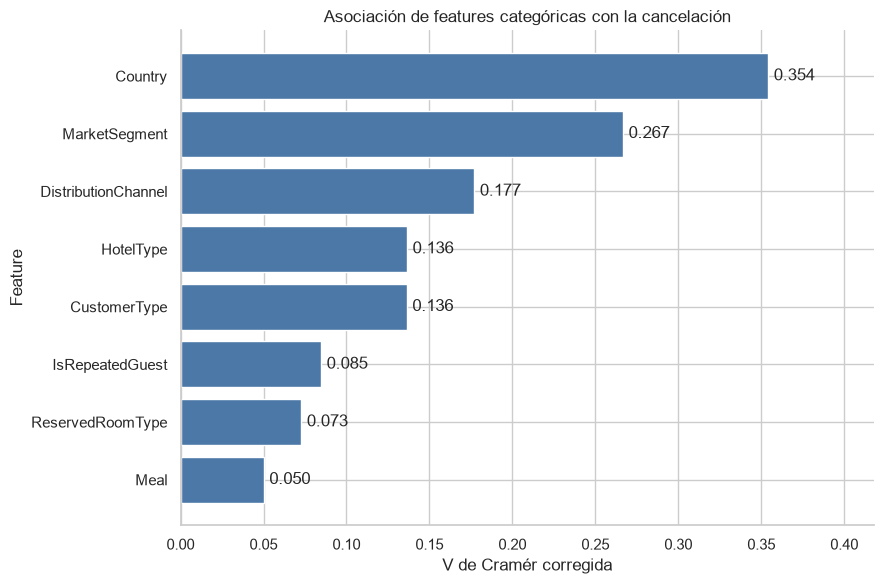

In [15]:
plot_data = categorical_association_summary.sort_values("cramers_v")
figure, axis = plt.subplots(figsize=(9, 6))
bars = axis.barh(
    plot_data["feature"],
    plot_data["cramers_v"],
    color="#4C78A8",
)
axis.bar_label(bars, fmt="%.3f", padding=4)
axis.set_title("Asociación de features categóricas con la cancelación")
axis.set_xlabel("V de Cramér corregida")
axis.set_ylabel("Feature")
axis.set_xlim(0, max(plot_data["cramers_v"].max() * 1.18, 0.05))
sns.despine(ax=axis)
figure.tight_layout()

if PROJECT_ROOT is not None:
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    categorical_association_path = (
        figures_dir / "feature_analysis_categorical_association.png"
    )
    figure.savefig(
        categorical_association_path, dpi=300, bbox_inches="tight"
    )
    print(f"Gráfica guardada en: {categorical_association_path}")

plt.show()

Los resultados de este bloque describen asociaciones marginales. Una relación pequeña no implica que la variable sea inútil: puede aportar información mediante interacciones o al controlar por otras features. Del mismo modo, una asociación grande puede reflejar segmentos comerciales o políticas del hotel y debe comprobarse dentro de la validación.

## Análisis condicionado de las asociaciones categóricas principales

`DepositType`, `Country` y `MarketSegment` presentan las mayores asociaciones marginales. Antes de considerarlas señales independientes se estudia si sus tasas están condicionadas por el hotel, los bloques repetidos o el peso de combinaciones exactas.

### Precaución temporal sobre `DepositType`

El nombre puede confundirse con la política contractual de una tarifa. En este dataset la variable fue construida a partir de pagos identificados antes de la llegada o cancelación: `Non Refund` indica que los pagos alcanzaron o superaron el costo total, `Refundable` que existió un pago parcial y `No Deposit` que no se encontraron pagos. Por tanto, el valor puede consolidar transacciones posteriores a la confirmación y no se considera automáticamente disponible en el momento principal de predicción. La definición original puede consultarse en [Hotel booking demand datasets](https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/).

In [16]:
confirmed_signature_ids = X_candidates.groupby(
    X_candidates.columns.tolist(),
    dropna=False,
    sort=False,
).ngroup()
confirmed_signature_sizes = confirmed_signature_ids.map(
    confirmed_signature_ids.value_counts()
)

categorical_context_df = X_candidates.assign(
    DepositType=bookings_df["DepositType"],
    IsCanceled=y,
    RepetitionStatus=np.where(
        confirmed_signature_sizes.gt(1),
        "Repeated confirmed signature",
        "Unique confirmed signature",
    ),
    ConfirmedSignatureSize=confirmed_signature_sizes,
)
categorical_context_df["CountryScope"] = np.select(
    [
        categorical_context_df["Country"].isna(),
        categorical_context_df["Country"].eq("PRT"),
    ],
    ["Missing", "PRT"],
    default="Other countries",
)

repetition_context_summary = (
    categorical_context_df.groupby("RepetitionStatus")
    .agg(
        rows=("IsCanceled", "size"),
        cancellation_rate=("IsCanceled", "mean"),
    )
    .reset_index()
)
display(repetition_context_summary)

,RepetitionStatus,rows,cancellation_rate
0,Repeated confirmed signature,44766,0.545749
1,Unique confirmed signature,74624,0.265236


In [17]:
def summarize_cancellation_by_context(df, feature, context):
    """Resume volumen y cancelación para una feature dentro de cada contexto."""
    summary = (
        df.groupby([context, feature], dropna=False)
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    summary["context_rows"] = summary.groupby(context)["rows"].transform("sum")
    summary["within_context_percentage"] = (
        summary["rows"] / summary["context_rows"] * 100
    )
    summary["cancellation_percentage"] = summary["cancellation_rate"] * 100
    return summary.drop(columns="context_rows")

### `DepositType` por hotel y repetición

Se comprueba si la tasa casi determinista de `Non Refund` se mantiene dentro de ambos hoteles y entre firmas únicas y repetidas.

In [18]:
deposit_by_hotel = summarize_cancellation_by_context(
    categorical_context_df, "DepositType", "HotelType"
)
deposit_by_repetition = summarize_cancellation_by_context(
    categorical_context_df, "DepositType", "RepetitionStatus"
)
display(deposit_by_hotel.round(4))
display(deposit_by_repetition.round(4))

,HotelType,DepositType,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,City Hotel,No Deposit,66442,20244,0.3047,83.7539,30.4687
1,City Hotel,Non Refund,12868,12844,0.9981,16.2208,99.8135
2,City Hotel,Refundable,20,14,0.7000,0.0252,70.0000
3,Resort Hotel,No Deposit,38199,9450,0.2474,95.3545,24.7389
4,Resort Hotel,Non Refund,1719,1650,0.9599,4.2911,95.9860
5,Resort Hotel,Refundable,142,22,0.1549,0.3545,15.4930


,RepetitionStatus,DepositType,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,Repeated confirmed signature,No Deposit,30310,10117,0.3338,67.7076,33.3784
1,Repeated confirmed signature,Non Refund,14348,14297,0.9964,32.0511,99.6445
2,Repeated confirmed signature,Refundable,108,17,0.1574,0.2413,15.7407
3,Unique confirmed signature,No Deposit,74331,19577,0.2634,99.6074,26.3376
4,Unique confirmed signature,Non Refund,239,197,0.8243,0.3203,82.4268
5,Unique confirmed signature,Refundable,54,19,0.3519,0.0724,35.1852


### País local frente a otros países

Portugal (`PRT`) concentra el 40,7 % del dataset y presenta una tasa alta. Para estudiar posibles factores de confusión se lo compara con el resto de países dentro de cada hotel y según la repetición. La agrupación `CountryScope` es exclusivamente diagnóstica.

In [19]:
country_by_hotel = summarize_cancellation_by_context(
    categorical_context_df, "CountryScope", "HotelType"
)
country_by_repetition = summarize_cancellation_by_context(
    categorical_context_df, "CountryScope", "RepetitionStatus"
)
display(country_by_hotel.round(4))
display(country_by_repetition.round(4))

,HotelType,CountryScope,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,City Hotel,Missing,24,22,0.9167,0.0303,91.6667
1,City Hotel,Other countries,48346,12999,0.2689,60.9429,26.8874
2,City Hotel,PRT,30960,20081,0.6486,39.0268,64.8611
3,Resort Hotel,Missing,464,45,0.0970,1.1583,9.6983
4,Resort Hotel,Other countries,21966,3639,0.1657,54.8328,16.5665
5,Resort Hotel,PRT,17630,7438,0.4219,44.0090,42.1894


,RepetitionStatus,CountryScope,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,Repeated confirmed signature,Missing,49,40,0.8163,0.1095,81.6327
1,Repeated confirmed signature,Other countries,18760,4169,0.2222,41.9068,22.2228
2,Repeated confirmed signature,PRT,25957,20222,0.7791,57.9837,77.9058
3,Unique confirmed signature,Missing,439,27,0.0615,0.5883,6.1503
4,Unique confirmed signature,Other countries,51552,12469,0.2419,69.0823,24.1872
5,Unique confirmed signature,PRT,22633,7297,0.3224,30.3294,32.2405


### `MarketSegment` por hotel y repetición

El segmento `Groups` tiene una tasa elevada y una gran concentración de bloques repetidos. Las tablas permiten observar si el segmento conserva diferencias dentro de cada contexto.

In [20]:
market_by_hotel = summarize_cancellation_by_context(
    categorical_context_df, "MarketSegment", "HotelType"
)
market_by_repetition = summarize_cancellation_by_context(
    categorical_context_df, "MarketSegment", "RepetitionStatus"
)
display(market_by_hotel.round(4))
display(market_by_repetition.round(4))

,HotelType,MarketSegment,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,City Hotel,Aviation,237,52,0.2194,0.2988,21.9409
1,City Hotel,Complementary,542,64,0.1181,0.6832,11.8081
2,City Hotel,Corporate,2986,641,0.2147,3.7640,21.4668
3,City Hotel,Direct,6093,1056,0.1733,7.6806,17.3314
4,City Hotel,Groups,13975,9623,0.6886,17.6163,68.8587
5,City Hotel,Offline TA/TO,16747,7173,0.4283,21.1106,42.8316
6,City Hotel,Online TA,38748,14491,0.3740,48.8441,37.3981
7,City Hotel,Undefined,2,2,1.0000,0.0025,100.0000
8,Resort Hotel,Complementary,201,33,0.1642,0.5017,16.4179
9,Resort Hotel,Corporate,2309,351,0.1520,5.7639,15.2014


,RepetitionStatus,MarketSegment,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,Repeated confirmed signature,Aviation,26,16,0.6154,0.0581,61.5385
1,Repeated confirmed signature,Complementary,103,19,0.1845,0.2301,18.4466
2,Repeated confirmed signature,Corporate,1737,617,0.3552,3.8802,35.5210
3,Repeated confirmed signature,Direct,1879,437,0.2326,4.1974,23.2571
4,Repeated confirmed signature,Groups,17857,11754,0.6582,39.8896,65.8229
5,Repeated confirmed signature,Offline TA/TO,13306,6939,0.5215,29.7235,52.1494
6,Repeated confirmed signature,Online TA,9858,4649,0.4716,22.0212,47.1597
7,Unique confirmed signature,Aviation,211,36,0.1706,0.2828,17.0616
8,Unique confirmed signature,Complementary,640,78,0.1219,0.8576,12.1875
9,Unique confirmed signature,Corporate,3558,375,0.1054,4.7679,10.5396


### Sensibilidad al peso de combinaciones exactas

Se compara la distribución original con una versión hipotética que conserva una sola fila por combinación exacta de predictores y target. Esta versión no reemplaza el dataset: permite medir cuánto dependen las tasas del peso de bloques idénticos.

In [21]:
candidate_analysis_df = X_candidates.assign(
    DepositType=bookings_df["DepositType"],
    IsCanceled=y,
)
candidate_deduplicated_df = candidate_analysis_df.drop_duplicates()
dataset_versions = {
    "Original": candidate_analysis_df,
    "One row per exact predictor-target combination": candidate_deduplicated_df,
}

dedup_sensitivity_records = []
for dataset_name, dataset_df in dataset_versions.items():
    dataset_with_scope = dataset_df.assign(
        CountryScope=np.select(
            [dataset_df["Country"].isna(), dataset_df["Country"].eq("PRT")],
            ["Missing", "PRT"],
            default="Other countries",
        )
    )
    for feature in ["DepositType", "CountryScope", "MarketSegment"]:
        feature_summary = (
            dataset_with_scope.groupby(feature, dropna=False)
            .agg(
                rows=("IsCanceled", "size"),
                cancellation_rate=("IsCanceled", "mean"),
            )
            .reset_index()
            .rename(columns={feature: "category"})
        )
        feature_summary.insert(0, "feature", feature)
        feature_summary.insert(0, "dataset", dataset_name)
        dedup_sensitivity_records.append(feature_summary)

dedup_sensitivity_summary = pd.concat(
    dedup_sensitivity_records, ignore_index=True
)
dedup_sensitivity_summary["cancellation_percentage"] = (
    dedup_sensitivity_summary["cancellation_rate"] * 100
)
display(dedup_sensitivity_summary.round(4))

,dataset,feature,category,rows,cancellation_rate,cancellation_percentage
0,Original,DepositType,No Deposit,104641,0.2838,28.3770
1,Original,DepositType,Non Refund,14587,0.9936,99.3624
2,Original,DepositType,Refundable,162,0.2222,22.2222
3,Original,CountryScope,Missing,488,0.1373,13.7295
4,Original,CountryScope,Other countries,70312,0.2366,23.6631
5,Original,CountryScope,PRT,48590,0.5664,56.6351
6,Original,MarketSegment,Aviation,237,0.2194,21.9409
7,Original,MarketSegment,Complementary,743,0.1306,13.0552
8,Original,MarketSegment,Corporate,5295,0.1873,18.7347
9,Original,MarketSegment,Direct,12606,0.1534,15.3419


Este bloque busca distinguir asociación propia de composición y repetición. En particular, `DepositType` quedará marcado como variable temporalmente riesgosa aunque mantenga una asociación alta; su inclusión deberá compararse explícitamente contra modelos que la excluyan.

## Auditoría temporal de `ADR`

La documentación define `ADR` como la suma de las transacciones de alojamiento dividida por la cantidad de noches. Sus fuentes incluyen las tablas de reservas, listas y transacciones, pero no se especifica un corte que garantice que el valor corresponda exactamente al precio conocido al confirmar. El análisis mostró además una asociación marginal pequeña y valores extremos que agregan complejidad. Ante una utilidad limitada frente al riesgo temporal, se excluye del conjunto principal y se conserva únicamente en `bookings_df` para documentar la decisión.

In [22]:
adr_analysis_df = bookings_df[["HotelType", "DepositType", "ADR"]].assign(
    IsCanceled=y
)

adr_target_summary = (
    adr_analysis_df.groupby("IsCanceled")["ADR"]
    .agg(
        rows="size",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)
adr_target_percentiles = (
    adr_analysis_df.groupby("IsCanceled")["ADR"]
    .quantile([0.01, 0.05, 0.25, 0.75, 0.95, 0.99])
    .unstack()
    .rename(columns={
        0.01: "p01", 0.05: "p05", 0.25: "p25",
        0.75: "p75", 0.95: "p95", 0.99: "p99",
    })
    .reset_index()
)
adr_target_summary = adr_target_summary.merge(
    adr_target_percentiles, on="IsCanceled"
)
display(adr_target_summary.round(3))

,IsCanceled,rows,mean,median,standard_deviation,minimum,maximum,p01,p05,p25,p75,p95,p99
0,0,75166,99.988,92.5,49.206,-6.38,510.0,0.0,35.0,67.500,125.00,192.0,252.0
1,1,44224,104.964,96.2,52.571,0.00,5400.0,26.0,48.0,72.415,127.62,195.0,252.0


In [23]:
adr_special_value_summary = []
for label, mask in {
    "ADR < 0": adr_analysis_df["ADR"].lt(0),
    "ADR = 0": adr_analysis_df["ADR"].eq(0),
    "ADR > p99": adr_analysis_df["ADR"].gt(adr_analysis_df["ADR"].quantile(0.99)),
    "ADR > 1000": adr_analysis_df["ADR"].gt(1000),
}.items():
    selected_target = adr_analysis_df.loc[mask, "IsCanceled"]
    adr_special_value_summary.append(
        {
            "case": label,
            "rows": mask.sum(),
            "percentage": mask.mean() * 100,
            "cancellation_rate": (
                selected_target.mean() if not selected_target.empty else np.nan
            ),
        }
    )

display(pd.DataFrame(adr_special_value_summary).round(4))

,case,rows,percentage,cancellation_rate
0,ADR < 0,1,0.0008,0.0000
1,ADR = 0,1959,1.6408,0.1087
2,ADR > p99,1168,0.9783,0.3647
3,ADR > 1000,1,0.0008,1.0000


### `ADR` por hotel, target y depósito

Las diferencias se desglosan para observar si la relación con la cancelación está dominada por el hotel o por la variable de depósito ya descartada.

In [24]:
adr_context_summary = (
    adr_analysis_df.groupby(["HotelType", "DepositType", "IsCanceled"])["ADR"]
    .agg(rows="size", mean="mean", median="median")
    .reset_index()
)
display(adr_context_summary.round(3))

,HotelType,DepositType,IsCanceled,rows,mean,median
0,City Hotel,No Deposit,0,46198,105.753,99.90
1,City Hotel,No Deposit,1,20244,112.007,106.20
2,City Hotel,Non Refund,0,24,99.778,106.00
3,City Hotel,Non Refund,1,12844,93.123,90.00
4,City Hotel,Refundable,0,6,78.042,81.00
5,City Hotel,Refundable,1,14,130.807,134.75
6,Resort Hotel,No Deposit,0,28749,90.934,72.41
7,Resort Hotel,No Deposit,1,9450,112.770,91.55
8,Resort Hotel,Non Refund,0,69,69.857,54.50
9,Resort Hotel,Non Refund,1,1650,66.073,70.00


Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_adr_by_target_hotel.png


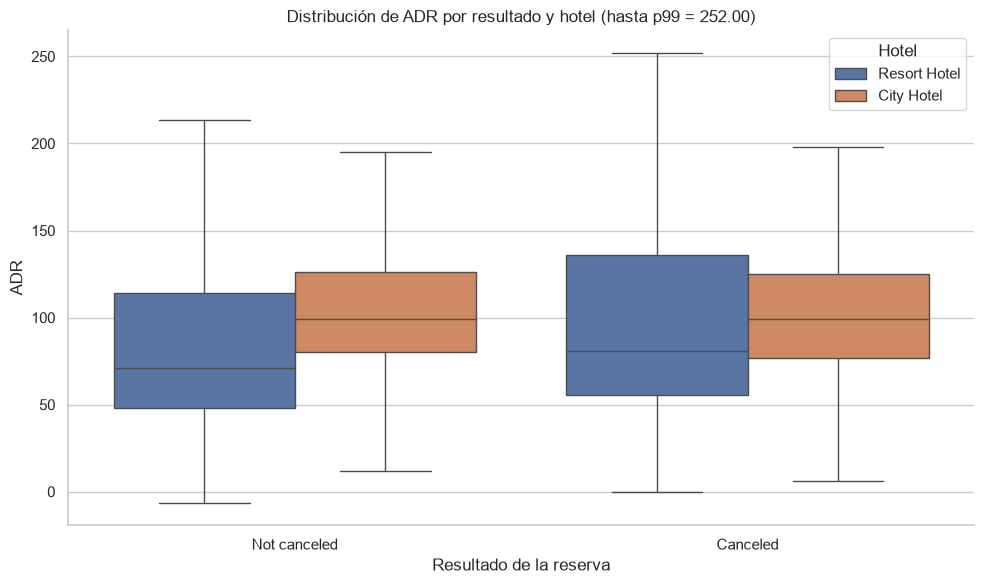

In [25]:
adr_visual_limit = adr_analysis_df["ADR"].quantile(0.99)
adr_plot_df = adr_analysis_df.loc[adr_analysis_df["ADR"].le(adr_visual_limit)].copy()
adr_plot_df["Reservation outcome"] = adr_plot_df["IsCanceled"].map(
    {0: "Not canceled", 1: "Canceled"}
)

figure, axis = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=adr_plot_df,
    x="Reservation outcome",
    y="ADR",
    hue="HotelType",
    showfliers=False,
    ax=axis,
)
axis.set_title(f"Distribución de ADR por resultado y hotel (hasta p99 = {adr_visual_limit:.2f})")
axis.set_xlabel("Resultado de la reserva")
axis.set_ylabel("ADR")
axis.legend(title="Hotel")
sns.despine(ax=axis)
figure.tight_layout()

if PROJECT_ROOT is not None:
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    adr_figure_path = figures_dir / "feature_analysis_adr_by_target_hotel.png"
    figure.savefig(adr_figure_path, dpi=300, bbox_inches="tight")
    print(f"Gráfica guardada en: {adr_figure_path}")

plt.show()

`ADR` se excluye del conjunto operativo principal. La decisión no se basa solamente en sus valores extremos: su procedencia transaccional impide garantizar que el valor del archivo sea el disponible al confirmar, mientras que las distribuciones de reservas canceladas y no canceladas mostraron diferencias pequeñas. El bloque se conserva como evidencia de esta exclusión.

## Análisis de `Agent` y `Company`

Ambas columnas contienen identificadores anonimizados, no magnitudes. Según la documentación, `NULL` significa que la reserva no provino de una agencia o no tuvo una empresa asociada; por tanto, es una ausencia estructural y debe representarse como una categoría informativa, no imputarse mediante la moda. El análisis separa la presencia de la identidad específica.

In [26]:
identifier_analysis_df = X_candidates[[
    "HotelType", "ArrivalDateYear", "Agent", "Company"
]].assign(IsCanceled=y)
identifier_analysis_df["HasAgent"] = identifier_analysis_df["Agent"].notna()
identifier_analysis_df["HasCompany"] = identifier_analysis_df["Company"].notna()
identifier_analysis_df["BookingIntermediaryStructure"] = np.select(
    [
        identifier_analysis_df["HasAgent"] & identifier_analysis_df["HasCompany"],
        identifier_analysis_df["HasAgent"],
        identifier_analysis_df["HasCompany"],
    ],
    ["Agent and company", "Agent only", "Company only"],
    default="Neither agent nor company",
)

identifier_presence_summary = (
    identifier_analysis_df.groupby("BookingIntermediaryStructure")
    .agg(
        rows=("IsCanceled", "size"),
        cancellations=("IsCanceled", "sum"),
        cancellation_rate=("IsCanceled", "mean"),
    )
    .reset_index()
)
identifier_presence_summary["dataset_percentage"] = (
    identifier_presence_summary["rows"] / len(identifier_analysis_df) * 100
)
display(identifier_presence_summary.round(4))

,BookingIntermediaryStructure,rows,cancellations,cancellation_rate,dataset_percentage
0,Agent and company,217,17,0.0783,0.1818
1,Agent only,102833,40177,0.3907,86.1320
2,Company only,6580,1174,0.1784,5.5113
3,Neither agent nor company,9760,2856,0.2926,8.1749


### Asociación de presencia e identidad

Se compara la asociación de los indicadores de presencia con la asociación de los IDs específicos. Para los identificadores se agrupan categorías con menos de 100 reservas sólo durante el cálculo, como en el análisis categórico anterior. Una asociación alta de los IDs puede reflejar políticas de determinados intermediarios, pero también puede inducir memorización.

In [27]:
identifier_association_features = {
    "HasAgent": identifier_analysis_df["HasAgent"],
    "HasCompany": identifier_analysis_df["HasCompany"],
    "BookingIntermediaryStructure": identifier_analysis_df["BookingIntermediaryStructure"],
    "Agent ID": prepare_categorical_for_association(X_candidates["Agent"]),
    "Company ID": prepare_categorical_for_association(X_candidates["Company"]),
}
identifier_association_records = []

for feature, values in identifier_association_features.items():
    contingency_table = pd.crosstab(values, y)
    association = corrected_cramers_v(contingency_table)
    identifier_association_records.append(
        {
            "feature": feature,
            "analyzed_categories": values.nunique(dropna=False),
            **association,
        }
    )

identifier_association_summary = (
    pd.DataFrame(identifier_association_records)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
display(identifier_association_summary.round(5))

,feature,analyzed_categories,chi2,p_value,degrees_of_freedom,cramers_v,minimum_expected_frequency,expected_cells_below_5
0,Agent ID,86,15506.79083,0.0,85,0.35941,37.04163,0
1,BookingIntermediaryStructure,4,1554.18722,0.0,3,0.11399,80.38033,0
2,Company ID,13,1509.34673,0.0,12,0.11199,42.22746,0
3,HasAgent,2,1243.16991,0.0,1,0.10200,6052.60206,0
4,HasCompany,2,1176.59375,0.0,1,0.09923,2517.71947,0


### Identificadores con soporte suficiente

Se muestran únicamente IDs con al menos 100 reservas. Las tasas de identificadores pequeños son demasiado inestables para interpretarlas individualmente y deberán agruparse o manejarse como categorías desconocidas durante el modelado.

In [28]:
MIN_IDENTIFIER_ROWS = 100
supported_identifier_tables = {}

for feature in ["Agent", "Company"]:
    identifier_values = X_candidates[feature].astype("string").fillna(
        f"No {feature}"
    )
    identifier_rates = (
        pd.DataFrame({feature: identifier_values, "IsCanceled": y})
        .groupby(feature)
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    identifier_rates["difference_from_global_pp"] = (
        identifier_rates["cancellation_rate"] - y.mean()
    ) * 100
    supported_identifier_rates = identifier_rates.loc[
        identifier_rates["rows"].ge(MIN_IDENTIFIER_ROWS)
    ].sort_values("rows", ascending=False)
    supported_identifier_tables[feature] = supported_identifier_rates

    print(
        f"{feature}: {len(identifier_rates)} categorías incluyendo ausencia; "
        f"{len(supported_identifier_rates)} con al menos {MIN_IDENTIFIER_ROWS} filas."
    )
    display(supported_identifier_rates.round(4))

Agent: 334 categorías incluyendo ausencia; 85 con al menos 100 filas.


,Agent,rows,cancellations,cancellation_rate,difference_from_global_pp
323,9,31961,13264,0.4150,4.4590
333,No Agent,16340,4030,0.2466,-12.3782
102,240,13922,5484,0.3939,2.3493
0,1,7191,5280,0.7343,36.3835
30,14,3640,652,0.1791,-19.1295
...,...,...,...,...,...
331,98,124,61,0.4919,12.1519
328,94,114,18,0.1579,-21.2522
189,35,109,65,0.5963,22.5914
92,220,104,1,0.0096,-36.0801


Company: 353 categorías incluyendo ausencia; 12 con al menos 100 filas.


,Company,rows,cancellations,cancellation_rate,difference_from_global_pp
352,No Company,112593,43033,0.3822,1.1783
217,40,927,77,0.0831,-28.7353
80,223,784,119,0.1518,-21.8631
328,67,267,175,0.6554,28.5014
258,45,250,28,0.1120,-25.8416
37,153,215,48,0.2233,-14.7160
48,174,149,21,0.1409,-22.9477
75,219,141,9,0.0638,-30.6586
120,281,138,17,0.1232,-24.7228
38,154,133,5,0.0376,-33.2822


### Estabilidad temporal de los identificadores

Para aproximar el riesgo de categorías desconocidas se consideran 2015 y 2016 como historia y se mide cuántos IDs presentes en 2017 no habían aparecido anteriormente. Una categoría nueva no puede recibir un coeficiente específico mediante one-hot encoding y un target encoding sería especialmente riesgoso si no se calcula dentro de cada fold.

In [29]:
identifier_temporal_records = []
historical_mask = X_candidates["ArrivalDateYear"].lt(2017)
future_mask = X_candidates["ArrivalDateYear"].eq(2017)

for feature in ["Agent", "Company"]:
    historical_ids = set(X_candidates.loc[historical_mask, feature].dropna().unique())
    future_values = X_candidates.loc[future_mask, feature]
    future_non_null = future_values.dropna()
    future_ids = set(future_non_null.unique())
    unseen_ids = future_ids - historical_ids
    unseen_row_mask = future_non_null.isin(unseen_ids)

    identifier_temporal_records.append(
        {
            "feature": feature,
            "historical_unique_ids": len(historical_ids),
            "future_unique_ids": len(future_ids),
            "unseen_future_ids": len(unseen_ids),
            "future_non_null_rows": len(future_non_null),
            "rows_with_unseen_id": unseen_row_mask.sum(),
            "unseen_row_percentage": (
                unseen_row_mask.mean() * 100 if len(future_non_null) else 0
            ),
        }
    )

identifier_temporal_summary = pd.DataFrame(identifier_temporal_records)
display(identifier_temporal_summary.round(4))

,feature,historical_unique_ids,future_unique_ids,unseen_future_ids,future_non_null_rows,rows_with_unseen_id,unseen_row_percentage
0,Agent,284,191,49,35023,1664,4.7512
1,Company,298,198,54,2310,384,16.6234


### Sensibilidad de la presencia a combinaciones repetidas

Se compara la estructura de intermediación en el dataset original y en una versión con una fila por combinación exacta de predictores y target. Esto permite observar si su tasa depende principalmente del peso de bloques repetidos.

In [30]:
identifier_dedup_records = []
identifier_candidate_df = X_candidates.assign(IsCanceled=y)
identifier_dataset_versions = {
    "Original": identifier_candidate_df,
    "One row per exact predictor-target combination": (
        identifier_candidate_df.drop_duplicates()
    ),
}

for dataset_name, dataset_df in identifier_dataset_versions.items():
    has_agent = dataset_df["Agent"].notna()
    has_company = dataset_df["Company"].notna()
    structure = np.select(
        [has_agent & has_company, has_agent, has_company],
        ["Agent and company", "Agent only", "Company only"],
        default="Neither agent nor company",
    )
    version_summary = (
        pd.DataFrame(
            {
                "BookingIntermediaryStructure": structure,
                "IsCanceled": dataset_df["IsCanceled"],
            }
        )
        .groupby("BookingIntermediaryStructure")
        .agg(rows=("IsCanceled", "size"), cancellation_rate=("IsCanceled", "mean"))
        .reset_index()
    )
    version_summary.insert(0, "dataset", dataset_name)
    identifier_dedup_records.append(version_summary)

identifier_dedup_summary = pd.concat(identifier_dedup_records, ignore_index=True)
display(identifier_dedup_summary.round(4))

,dataset,BookingIntermediaryStructure,rows,cancellation_rate
0,Original,Agent and company,217,0.0783
1,Original,Agent only,102833,0.3907
2,Original,Company only,6580,0.1784
3,Original,Neither agent nor company,9760,0.2926
4,One row per exact predictor-target combination,Agent and company,168,0.0893
5,One row per exact predictor-target combination,Agent only,72426,0.3028
6,One row per exact predictor-target combination,Company only,4701,0.1125
7,One row per exact predictor-target combination,Neither agent nor company,6791,0.1387


La ausencia de agencia o empresa se conservará como información explícita. La identidad específica no se incorporará automáticamente: deberá compararse contra una representación más estable basada en `HasAgent`, `HasCompany` y agrupación de IDs infrecuentes. Cualquier codificación aprendida a partir del target deberá calcularse exclusivamente dentro de los folds de entrenamiento.

## Decisión sobre identificadores

Los IDs específicos de `Agent` y `Company` no se utilizarán en el conjunto principal. Aunque `Agent` presenta una asociación marginal importante, ambos identificadores representan actores particulares y muestran categorías nuevas en el período más reciente. Un modelo basado en esos códigos podría memorizar el comportamiento histórico de intermediarios concretos y degradarse cuando aparezcan agencias o empresas nuevas.

Se conservarán únicamente `HasAgent` y `HasCompany`. Estos indicadores representan una característica estructural de la reserva —la participación de un intermediario o una empresa—, permiten representar correctamente los `NULL` como «no aplica» y son estables ante la aparición de nuevos IDs. La decisión prioriza generalización y simplicidad frente a una posible mejora basada en memorizar categorías específicas.

In [31]:
X_structured_candidates = (
    X_candidates.drop(columns=["Agent", "Company"])
    .assign(
        HasAgent=X_candidates["Agent"].notna().astype("int8"),
        HasCompany=X_candidates["Company"].notna().astype("int8"),
    )
)

if {"Agent", "Company"}.intersection(X_structured_candidates.columns):
    raise ValueError("Los identificadores originales continúan en el conjunto estructurado.")
if not {"HasAgent", "HasCompany"}.issubset(X_structured_candidates.columns):
    raise ValueError("No se crearon los indicadores de presencia esperados.")

print(
    f"Conjunto estructurado: {X_structured_candidates.shape[1]} features; "
    "Agent y Company reemplazadas por indicadores de presencia."
)

Conjunto estructurado: 25 features; Agent y Company reemplazadas por indicadores de presencia.


## Asociación de variables numéricas con el target

Se analizan primero las duraciones y conteos. Los componentes de calendario se estudiarán aparte porque poseen orden temporal y comportamiento cíclico. Las distribuciones son asimétricas y contienen muchos ceros, por lo que ninguna medida individual resulta suficiente.

### Métricas utilizadas

La correlación punto-biserial equivale a una correlación lineal entre una variable numérica y el target binario. Spearman detecta relaciones monotónicas mediante rangos y es menos sensible a escala y extremos. La ROC AUC univariada mide qué tan bien una feature ordena reservas canceladas por encima de no canceladas; se presenta orientada para que valores superiores a 0,5 indiquen capacidad de separación y se informa la dirección original.

In [32]:
NUMERIC_TARGET_FEATURES = [
    *FEATURE_GROUPS["Duration"],
    *FEATURE_GROUPS["Count"],
]
numeric_target_records = []

for feature in NUMERIC_TARGET_FEATURES:
    feature_frame = pd.DataFrame(
        {"value": X_structured_candidates[feature], "target": y}
    ).dropna()
    values = feature_frame["value"]
    target_values = feature_frame["target"]

    point_biserial, point_biserial_p = pointbiserialr(
        target_values, values
    )
    spearman_correlation, spearman_p = spearmanr(
        target_values, values
    )
    raw_auc = roc_auc_score(target_values, values)
    oriented_auc = max(raw_auc, 1 - raw_auc)
    auc_direction = (
        "Higher values → more cancellation"
        if raw_auc >= 0.5
        else "Higher values → less cancellation"
    )

    not_canceled_values = values.loc[target_values.eq(0)]
    canceled_values = values.loc[target_values.eq(1)]
    numeric_target_records.append(
        {
            "feature": feature,
            "valid_rows": len(feature_frame),
            "mean_not_canceled": not_canceled_values.mean(),
            "mean_canceled": canceled_values.mean(),
            "median_not_canceled": not_canceled_values.median(),
            "median_canceled": canceled_values.median(),
            "zero_rate_not_canceled": not_canceled_values.eq(0).mean(),
            "zero_rate_canceled": canceled_values.eq(0).mean(),
            "point_biserial": point_biserial,
            "point_biserial_p_value": point_biserial_p,
            "spearman": spearman_correlation,
            "spearman_p_value": spearman_p,
            "raw_univariate_auc": raw_auc,
            "oriented_univariate_auc": oriented_auc,
            "auc_direction": auc_direction,
        }
    )

numeric_target_summary = (
    pd.DataFrame(numeric_target_records)
    .sort_values("oriented_univariate_auc", ascending=False)
    .reset_index(drop=True)
)
display(numeric_target_summary.round(5))

,feature,valid_rows,mean_not_canceled,mean_canceled,median_not_canceled,median_canceled,zero_rate_not_canceled,zero_rate_canceled,point_biserial,point_biserial_p_value,spearman,spearman_p_value,raw_univariate_auc,oriented_univariate_auc,auc_direction
0,LeadTime,119390,79.98469,144.84882,45.0,113.0,0.07869,0.00972,0.29312,0.00000,0.31663,0.00000,0.68926,0.68926,Higher values → more cancellation
1,TotalOfSpecialRequests,119390,0.71406,0.32883,1.0,0.0,0.48908,0.75877,-0.23466,0.00000,-0.25852,0.00000,0.36414,0.63586,Higher values → less cancellation
2,PreviousCancellations,119390,0.01579,0.20835,0.0,0.0,0.99279,0.86564,0.11013,0.00000,0.27023,0.00000,0.56341,0.56341,Higher values → more cancellation
3,RequiredCarParkingSpaces,119390,0.09930,0.00000,0.0,0.0,0.90134,1.00000,-0.19550,0.00000,-0.19740,0.00000,0.45067,0.54933,Higher values → less cancellation
4,Adults,119390,1.82974,1.90173,2.0,2.0,0.00391,0.00246,0.06002,0.00000,0.06703,0.00000,0.53022,0.53022,Higher values → more cancellation
5,StaysInWeekNights,119390,2.46405,2.56191,2.0,2.0,0.07626,0.04326,0.02476,0.00000,0.04142,0.00000,0.52417,0.52417,Higher values → more cancellation
6,PreviousBookingsNotCanceled,119390,0.20298,0.02512,0.0,0.0,0.95450,0.99548,-0.05736,0.00000,-0.11535,0.00000,0.47952,0.52048,Higher values → less cancellation
7,DaysInWaitingList,119390,1.58987,3.56408,0.0,0.0,0.98219,0.94666,0.05419,0.00000,0.09824,0.00000,0.51762,0.51762,Higher values → more cancellation
8,Babies,119390,0.01038,0.00382,0.0,0.0,0.99002,0.99622,-0.03249,0.00000,-0.03431,0.00000,0.49690,0.50310,Higher values → less cancellation
9,StaysInWeekendNights,119390,0.92897,0.92527,1.0,1.0,0.43234,0.44096,-0.00179,0.53601,-0.00411,0.15603,0.49770,0.50230,Higher values → less cancellation


### Capacidad de separación univariada

La referencia 0,5 representa una feature sin capacidad de ordenamiento individual. Una AUC cercana a 0,5 no implica que la variable sea inútil en un modelo multivariado: puede aportar mediante interacciones o relaciones no monotónicas.

Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_numeric_univariate_auc.png


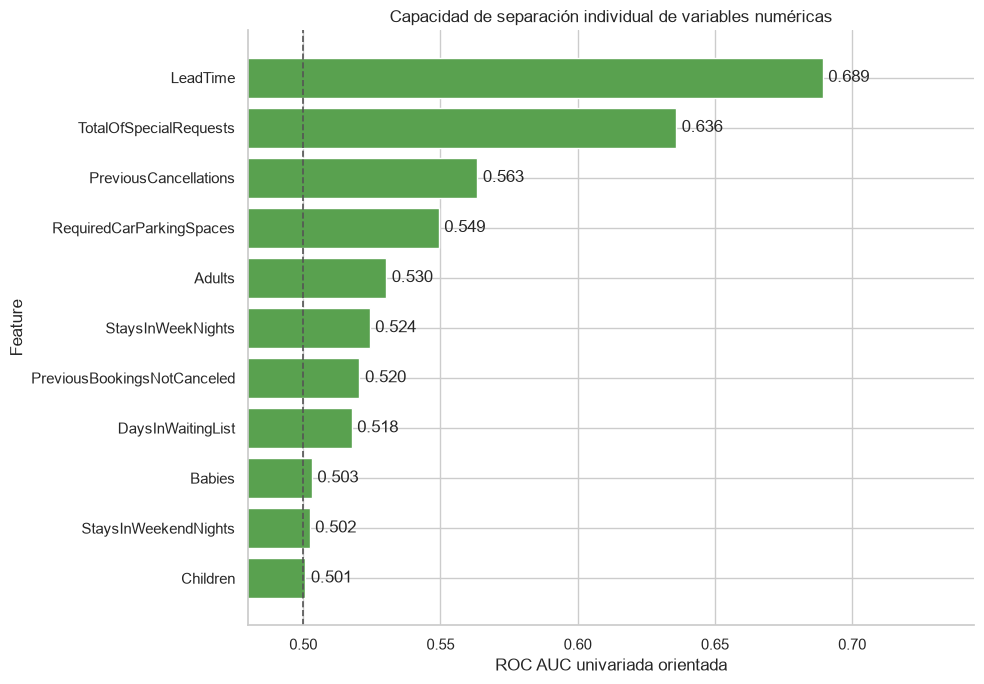

In [33]:
numeric_auc_plot_data = numeric_target_summary.sort_values(
    "oriented_univariate_auc"
)
figure, axis = plt.subplots(figsize=(10, 7))
bars = axis.barh(
    numeric_auc_plot_data["feature"],
    numeric_auc_plot_data["oriented_univariate_auc"],
    color="#59A14F",
)
axis.axvline(0.5, color="#555555", linestyle="--", linewidth=1.2)
axis.bar_label(bars, fmt="%.3f", padding=4)
axis.set_title("Capacidad de separación individual de variables numéricas")
axis.set_xlabel("ROC AUC univariada orientada")
axis.set_ylabel("Feature")
axis.set_xlim(0.48, max(numeric_auc_plot_data["oriented_univariate_auc"].max() * 1.08, 0.6))
sns.despine(ax=axis)
figure.tight_layout()

if PROJECT_ROOT is not None:
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    numeric_auc_path = figures_dir / "feature_analysis_numeric_univariate_auc.png"
    figure.savefig(numeric_auc_path, dpi=300, bbox_inches="tight")
    print(f"Gráfica guardada en: {numeric_auc_path}")

plt.show()

Este primer resumen identifica relaciones marginales y su dirección. Antes de seleccionar o transformar variables será necesario revisar las distribuciones de las más prometedoras, posibles relaciones no lineales y la colinealidad entre duraciones y conteos.

## Forma de las principales relaciones numéricas

`LeadTime` y `TotalOfSpecialRequests` presentan la mayor capacidad de separación individual. `PreviousCancellations` y `RequiredCarParkingSpaces` muestran diferencias importantes entre cero y valores positivos, aunque su AUC es menor porque la mayoría de las reservas se concentra en cero. Se construyen intervalos interpretables sólo para describir la forma de las relaciones; todavía no se decide utilizarlos como features.

In [34]:
def summarize_cancellation_profile(category_values, target_values, category_name):
    """Resume frecuencia y cancelación para categorías ordenadas o discretas."""
    profile = (
        pd.DataFrame({category_name: category_values, "IsCanceled": target_values})
        .groupby(category_name, observed=True, dropna=False)
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    profile["dataset_percentage"] = profile["rows"] / len(target_values) * 100
    profile["cancellation_percentage"] = profile["cancellation_rate"] * 100
    return profile

### Anticipación de la reserva

Los intervalos distinguen reservas para el mismo día, dentro de una semana, un mes, tres meses, seis meses, un año y más de un año.

In [35]:
lead_time_band = pd.cut(
    X_structured_candidates["LeadTime"],
    bins=[-1, 0, 7, 30, 90, 180, 365, np.inf],
    labels=["Same day", "1-7 days", "8-30 days", "31-90 days",
            "91-180 days", "181-365 days", "More than 365 days"],
)
lead_time_profile = summarize_cancellation_profile(
    lead_time_band, y, "LeadTimeBand"
)
display(lead_time_profile.round(4))

,LeadTimeBand,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_percentage
0,Same day,6345,430,0.0678,5.3145,6.7770
1,1-7 days,13401,1472,0.1098,11.2246,10.9843
2,8-30 days,18960,5283,0.2786,15.8807,27.8639
3,31-90 days,29553,11141,0.3770,24.7533,37.6984
4,91-180 days,26439,11821,0.4471,22.1451,44.7105
5,181-365 days,21544,11947,0.5545,18.0451,55.4540
6,More than 365 days,3148,2130,0.6766,2.6367,67.6620


### Solicitudes, historial y estacionamiento

Las solicitudes especiales se mantienen como conteo exacto. Para el historial y el estacionamiento se agrupan valores altos con poco soporte, preservando la diferencia principal entre ausencia y presencia.

In [36]:
special_requests_profile = summarize_cancellation_profile(
    X_structured_candidates["TotalOfSpecialRequests"],
    y,
    "TotalOfSpecialRequests",
)

previous_cancellation_band = pd.cut(
    X_structured_candidates["PreviousCancellations"],
    bins=[-1, 0, 1, np.inf],
    labels=["0", "1", "2 or more"],
)
previous_cancellations_profile = summarize_cancellation_profile(
    previous_cancellation_band, y, "PreviousCancellationsBand"
)

parking_presence = np.where(
    X_structured_candidates["RequiredCarParkingSpaces"].gt(0),
    "At least one space",
    "No parking requested",
)
parking_profile = summarize_cancellation_profile(
    parking_presence, y, "ParkingRequirement"
)

display(special_requests_profile.round(4))
display(previous_cancellations_profile.round(4))
display(parking_profile.round(4))

,TotalOfSpecialRequests,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_percentage
0,0,70318,33556,0.4772,58.8977,47.7204
1,1,33226,7318,0.2202,27.8298,22.0249
2,2,12969,2866,0.2210,10.8627,22.0989
3,3,2497,446,0.1786,2.0915,17.8614
4,4,340,36,0.1059,0.2848,10.5882
5,5,40,2,0.0500,0.0335,5.0000


,PreviousCancellationsBand,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_percentage
0,0,112906,38282,0.3391,94.5691,33.9061
1,1,6051,5714,0.9443,5.0683,94.4307
2,2 or more,433,228,0.5266,0.3627,52.6559


,ParkingRequirement,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_percentage
0,At least one space,7416,0,0.0000,6.2116,0.0000
1,No parking requested,111974,44224,0.3949,93.7884,39.4949


### Días en lista de espera

Como más del 96 % de las reservas tiene valor cero, se utilizan intervalos para comprobar si los pocos valores positivos presentan un patrón consistente o si la relación depende de grupos aislados.

In [37]:
waiting_list_band = pd.cut(
    X_structured_candidates["DaysInWaitingList"],
    bins=[-1, 0, 7, 30, 90, np.inf],
    labels=["0", "1-7 days", "8-30 days", "31-90 days", "More than 90 days"],
)
waiting_list_profile = summarize_cancellation_profile(
    waiting_list_band, y, "WaitingListBand"
)
display(waiting_list_profile.round(4))

,WaitingListBand,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_percentage
0,0,115692,41865,0.3619,96.9026,36.1866
1,1-7 days,129,79,0.6124,0.1080,61.2403
2,8-30 days,463,368,0.7948,0.3878,79.4816
3,31-90 days,2138,1395,0.6525,1.7908,65.2479
4,More than 90 days,968,517,0.5341,0.8108,53.4091


### Visualización de los perfiles

Las tasas se representan junto con la referencia global. La cantidad de filas de cada intervalo debe considerarse antes de interpretar diferencias extremas.

Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_numeric_profiles.png


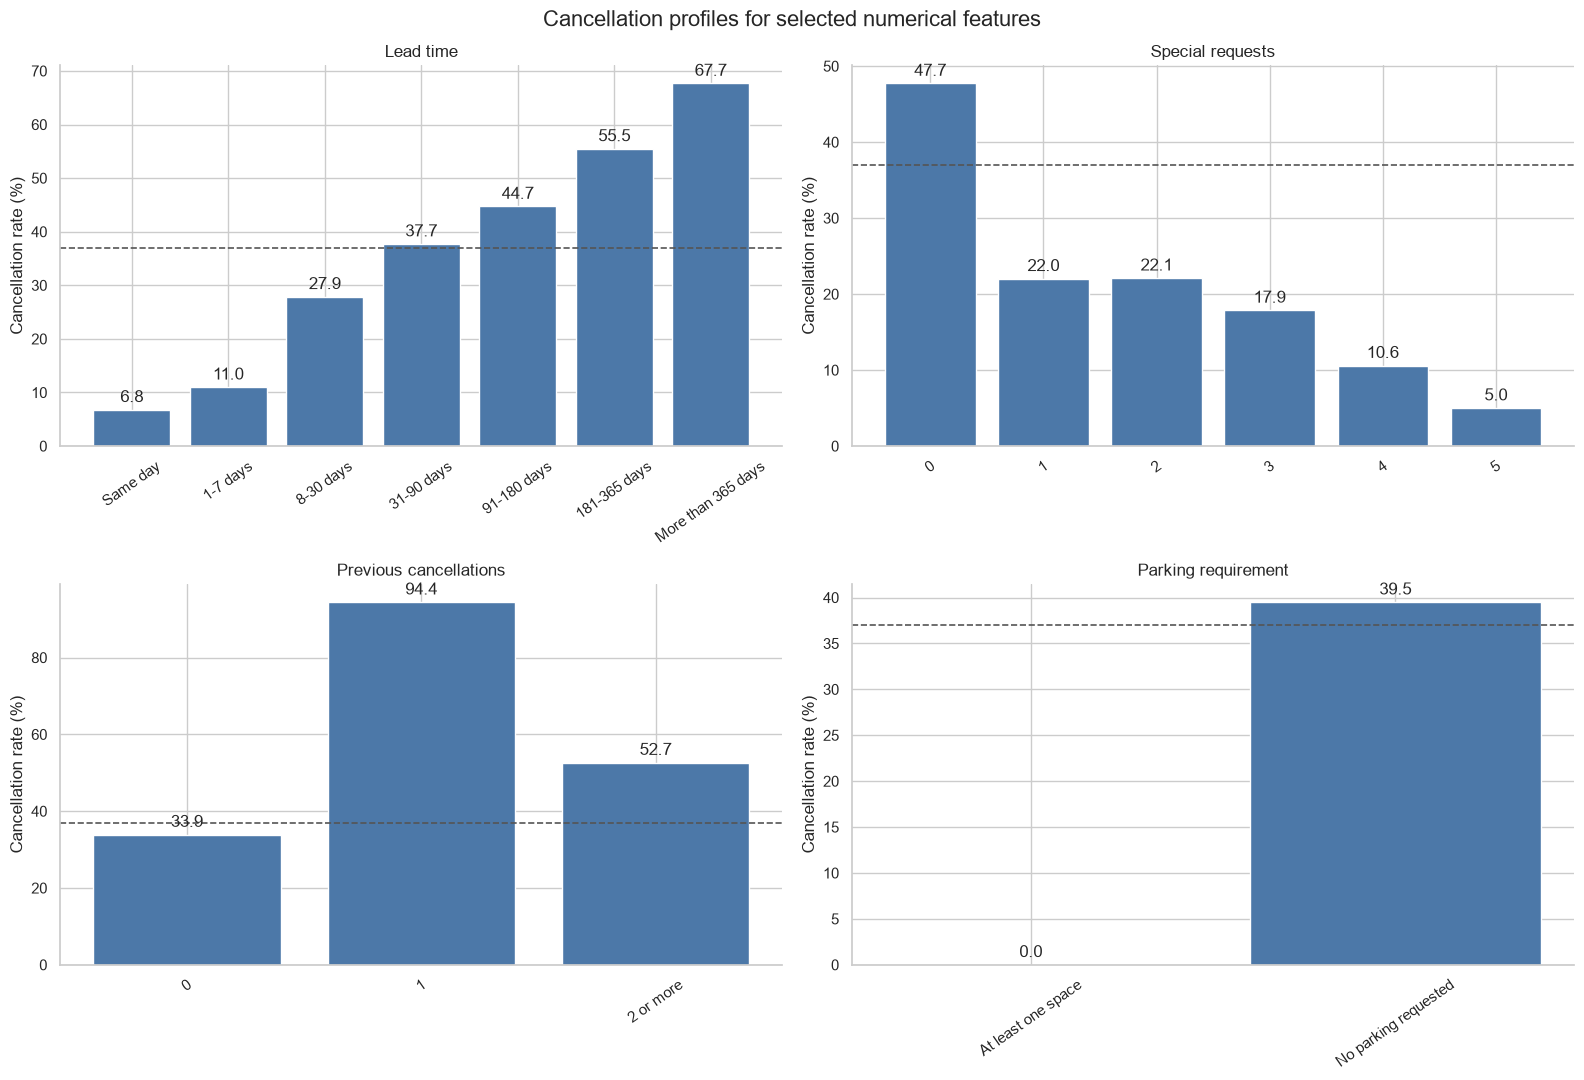

In [38]:
profile_plots = [
    (lead_time_profile, "LeadTimeBand", "Lead time"),
    (special_requests_profile, "TotalOfSpecialRequests", "Special requests"),
    (previous_cancellations_profile, "PreviousCancellationsBand", "Previous cancellations"),
    (parking_profile, "ParkingRequirement", "Parking requirement"),
]
figure, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for axis, (profile, category_column, title) in zip(axes, profile_plots):
    bars = axis.bar(
        profile[category_column].astype(str),
        profile["cancellation_percentage"],
        color="#4C78A8",
    )
    axis.axhline(
        y.mean() * 100, color="#555555", linestyle="--", linewidth=1.2
    )
    axis.set_title(title)
    axis.set_ylabel("Cancellation rate (%)")
    axis.tick_params(axis="x", rotation=35)
    axis.bar_label(bars, fmt="%.1f", padding=3)
    sns.despine(ax=axis)

figure.suptitle("Cancellation profiles for selected numerical features", fontsize=16)
figure.tight_layout()

if PROJECT_ROOT is not None:
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    numeric_profiles_path = figures_dir / "feature_analysis_numeric_profiles.png"
    figure.savefig(numeric_profiles_path, dpi=300, bbox_inches="tight")
    print(f"Gráfica guardada en: {numeric_profiles_path}")

plt.show()

Los intervalos son herramientas descriptivas y no reemplazan los valores originales. Su utilidad como features deberá compararse dentro de la validación, especialmente para modelos lineales que no capturan automáticamente relaciones por umbrales.

## Estabilidad de la señal de lista de espera

Aunque sólo el 3,1 % de las reservas permaneció algún tiempo en lista de espera, el grupo contiene 3.698 observaciones y presenta una tasa de cancelación elevada. Se comprueba si la diferencia entre cero y positivo se mantiene por hotel, año y repetición, y si sobrevive al reducir el peso de combinaciones exactas.

In [39]:
waiting_list_stability_df = X_structured_candidates.assign(IsCanceled=y)
waiting_list_stability_df["WasOnWaitingList"] = np.where(
    waiting_list_stability_df["DaysInWaitingList"].gt(0),
    "Positive waiting time",
    "No waiting time",
)

structured_signature_columns = X_structured_candidates.columns.tolist()
structured_signature_ids = X_structured_candidates.groupby(
    structured_signature_columns, dropna=False, sort=False
).ngroup()
structured_signature_sizes = structured_signature_ids.map(
    structured_signature_ids.value_counts()
)
waiting_list_stability_df["RepetitionStatus"] = np.where(
    structured_signature_sizes.gt(1),
    "Repeated structured signature",
    "Unique structured signature",
)

In [40]:
def summarize_waiting_list_by_context(df, context):
    summary = (
        df.groupby([context, "WasOnWaitingList"], dropna=False)
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    summary["context_percentage"] = (
        summary["rows"]
        / summary.groupby(context)["rows"].transform("sum")
        * 100
    )
    summary["cancellation_percentage"] = summary["cancellation_rate"] * 100
    return summary

### Comparación por hotel, año y repetición

Además de la tasa se muestra qué porcentaje representa cada estado dentro del contexto. Una diferencia con muy pocas filas o restringida a un único período sería menos confiable.

In [41]:
waiting_list_by_hotel = summarize_waiting_list_by_context(
    waiting_list_stability_df, "HotelType"
)
waiting_list_by_year = summarize_waiting_list_by_context(
    waiting_list_stability_df, "ArrivalDateYear"
)
waiting_list_by_repetition = summarize_waiting_list_by_context(
    waiting_list_stability_df, "RepetitionStatus"
)

display(waiting_list_by_hotel.round(4))
display(waiting_list_by_year.round(4))
display(waiting_list_by_repetition.round(4))

,HotelType,WasOnWaitingList,rows,cancellations,cancellation_rate,context_percentage,cancellation_percentage
0,City Hotel,No waiting time,75887,30760,0.4053,95.6599,40.5340
1,City Hotel,Positive waiting time,3443,2342,0.6802,4.3401,68.0221
2,Resort Hotel,No waiting time,39805,11105,0.2790,99.3635,27.8985
3,Resort Hotel,Positive waiting time,255,17,0.0667,0.6365,6.6667


,ArrivalDateYear,WasOnWaitingList,rows,cancellations,cancellation_rate,context_percentage,cancellation_percentage
0,2015,No waiting time,21247,7978,0.3755,96.5948,37.5488
1,2015,Positive waiting time,749,164,0.2190,3.4052,21.8959
2,2016,No waiting time,53958,18254,0.3383,95.1523,33.8300
3,2016,Positive waiting time,2749,2083,0.7577,4.8477,75.7730
4,2017,No waiting time,40487,15633,0.3861,99.5084,38.6124
5,2017,Positive waiting time,200,112,0.5600,0.4916,56.0000


,RepetitionStatus,WasOnWaitingList,rows,cancellations,cancellation_rate,context_percentage,cancellation_percentage
0,Repeated structured signature,No waiting time,41628,22254,0.5346,92.7024,53.4592
1,Repeated structured signature,Positive waiting time,3277,2208,0.6738,7.2976,67.3787
2,Unique structured signature,No waiting time,74064,19611,0.2648,99.4348,26.4785
3,Unique structured signature,Positive waiting time,421,151,0.3587,0.5652,35.8670


### Sensibilidad al peso de combinaciones repetidas

La comparación deduplicada conserva una fila por combinación exacta de las features estructuradas y el target. No reemplaza el dataset, sino que permite observar si la tasa positiva está dominada por bloques idénticos.

In [42]:
waiting_list_dedup_records = []
waiting_list_versions = {
    "Original": waiting_list_stability_df,
    "One row per exact structured predictor-target combination": (
        waiting_list_stability_df.drop(
            columns=["RepetitionStatus"]
        ).drop_duplicates()
    ),
}

for dataset_name, dataset_df in waiting_list_versions.items():
    version_summary = (
        dataset_df.groupby("WasOnWaitingList")
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    version_summary.insert(0, "dataset", dataset_name)
    waiting_list_dedup_records.append(version_summary)

waiting_list_dedup_summary = pd.concat(
    waiting_list_dedup_records, ignore_index=True
)
waiting_list_dedup_summary["cancellation_percentage"] = (
    waiting_list_dedup_summary["cancellation_rate"] * 100
)
display(waiting_list_dedup_summary.round(4))

,dataset,WasOnWaitingList,rows,cancellations,cancellation_rate,cancellation_percentage
0,Original,No waiting time,115692,41865,0.3619,36.1866
1,Original,Positive waiting time,3698,2359,0.6379,63.7912
2,One row per exact structured predictor-target ...,No waiting time,83336,23137,0.2776,27.7635
3,One row per exact structured predictor-target ...,Positive waiting time,688,273,0.3968,39.6802


La asociación de la lista de espera con la cancelación no es homogénea: cambia de dirección según el hotel, varía entre años y se reduce al controlar el peso de las combinaciones repetidas. Por ello, `DaysInWaitingList` se conserva provisionalmente para modelos basados en árboles, capaces de capturar interacciones y relaciones no lineales. `WasOnWaitingList` queda como candidata diagnóstica y no como reemplazo automático; para modelos lineales sólo debería evaluarse junto con su interacción con `HotelType`. Su aporte definitivo se comprobará mediante validación y ablación.

## Huéspedes y noches de estadía

Para cerrar el análisis numérico se estudian conjuntamente `Adults`, `Children`, `Babies`, `StaysInWeekendNights` y `StaysInWeekNights`. Además de revisar valores extremos y combinaciones inconsistentes, se evalúan dos variables derivadas naturales: cantidad total de huéspedes y cantidad total de noches. En esta etapa son variables diagnósticas; su incorporación definitiva se decidirá en Feature Engineering.

In [43]:
guests_nights_df = X_structured_candidates[[
    "HotelType", "Adults", "Children", "Babies",
    "StaysInWeekendNights", "StaysInWeekNights",
]].copy()
guests_nights_df["TotalGuests"] = guests_nights_df[["Adults", "Children", "Babies"]].sum(axis=1)
guests_nights_df["TotalNights"] = guests_nights_df[["StaysInWeekendNights", "StaysInWeekNights"]].sum(axis=1)
guests_nights_df["IsCanceled"] = y.to_numpy()

conditions = {
    "No guests": guests_nights_df["TotalGuests"].eq(0),
    "Zero nights": guests_nights_df["TotalNights"].eq(0),
    "No guests and zero nights": guests_nights_df["TotalGuests"].eq(0) & guests_nights_df["TotalNights"].eq(0),
    "More than 10 guests": guests_nights_df["TotalGuests"].gt(10),
    "More than 30 nights": guests_nights_df["TotalNights"].gt(30),
}
consistency_summary = pd.DataFrame([
    {
        "condition": name,
        "rows": mask.sum(),
        "dataset_percentage": mask.mean() * 100,
        "cancellation_percentage": guests_nights_df.loc[mask, "IsCanceled"].mean() * 100,
    }
    for name, mask in conditions.items()
])
display(consistency_summary.round(4))

,condition,rows,dataset_percentage,cancellation_percentage
0,No guests,180,0.1508,13.8889
1,Zero nights,715,0.5989,4.8951
2,No guests and zero nights,70,0.0586,17.1429
3,More than 10 guests,14,0.0117,92.8571
4,More than 30 nights,24,0.0201,20.8333


### Perfiles de huéspedes y duración

Los valores altos se agrupan para evitar conclusiones basadas en categorías con muy pocas observaciones. También se separa la duración por tipo de hotel, ya que una misma estadía puede representar comportamientos diferentes en hoteles urbanos y vacacionales.

In [44]:
guests_nights_df["TotalGuestsBand"] = pd.cut(
    guests_nights_df["TotalGuests"], bins=[-1, 0, 1, 2, 3, 4, np.inf],
    labels=["0", "1", "2", "3", "4", "5+"],
)
guests_nights_df["TotalNightsBand"] = pd.cut(
    guests_nights_df["TotalNights"], bins=[-1, 0, 1, 2, 3, 7, 14, np.inf],
    labels=["0", "1", "2", "3", "4-7", "8-14", "15+"],
)
total_guests_profile = summarize_cancellation_profile(
    guests_nights_df["TotalGuestsBand"], guests_nights_df["IsCanceled"], "TotalGuestsProfile"
)
total_nights_profile = summarize_cancellation_profile(
    guests_nights_df["TotalNightsBand"], guests_nights_df["IsCanceled"], "TotalNightsProfile"
)
nights_by_hotel = (
    guests_nights_df.groupby(["HotelType", "TotalNightsBand"], observed=True)
    .agg(rows=("IsCanceled", "size"), cancellation_rate=("IsCanceled", "mean"))
    .reset_index()
)
nights_by_hotel["cancellation_percentage"] = nights_by_hotel["cancellation_rate"] * 100
display(total_guests_profile)
display(total_nights_profile)
display(nights_by_hotel.round(4))

,TotalGuestsProfile,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_percentage
0,0,180,25,0.138889,0.150766,13.888889
1,1,22581,6555,0.290288,18.913644,29.028830
2,2,82051,32572,0.396973,68.725186,39.697261
3,3,10495,3377,0.321772,8.790518,32.177227
4,4,3929,1646,0.418936,3.290895,41.893612
5,5+,154,49,0.318182,0.128989,31.818182


,TotalNightsProfile,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_percentage
0,0,715,35,0.048951,0.598878,4.895105
1,1,21020,5271,0.250761,17.606165,25.076118
2,2,27643,12163,0.440003,23.153530,44.000289
3,3,27076,11351,0.419227,22.678616,41.922736
4,4-7,37679,13525,0.358953,31.559595,35.895326
5,8-14,4818,1636,0.339560,4.035514,33.955998
6,15+,439,243,0.553531,0.367702,55.353075


,HotelType,TotalNightsBand,rows,cancellation_rate,cancellation_percentage
0,City Hotel,0,331,0.0695,6.9486
1,City Hotel,1,13272,0.3091,30.9147
2,City Hotel,2,21426,0.4870,48.6978
3,City Hotel,3,21381,0.4437,44.3665
4,City Hotel,4-7,21672,0.3867,38.6674
5,City Hotel,8-14,1086,0.5138,51.3812
6,City Hotel,15+,162,0.7284,72.8395
7,Resort Hotel,0,384,0.0312,3.1250
8,Resort Hotel,1,7748,0.1507,15.0749
9,Resort Hotel,2,6217,0.2781,27.8108


### Aporte marginal de las variables derivadas

Se compara la capacidad discriminante individual de los componentes originales con `TotalGuests` y `TotalNights`. Un ROC AUC cercano a 0,5 no implica que una variable sea inútil dentro de un modelo multivariado, pero permite identificar si la suma aporta una señal más clara que sus componentes por separado.

In [45]:
guest_night_variables = [
    "Adults", "Children", "Babies", "TotalGuests",
    "StaysInWeekendNights", "StaysInWeekNights", "TotalNights",
]
guest_night_univariate_records = []
for column in guest_night_variables:
    values = guests_nights_df[column]
    valid_mask = values.notna()
    valid_values = values.loc[valid_mask]
    valid_target = guests_nights_df.loc[valid_mask, "IsCanceled"]
    auc = roc_auc_score(valid_target, valid_values)
    guest_night_univariate_records.append({
        "feature": column,
        "spearman": valid_values.corr(valid_target, method="spearman"),
        "roc_auc": auc,
        "oriented_roc_auc": max(auc, 1 - auc),
        "unique_values": valid_values.nunique(),
    })
guest_night_univariate = pd.DataFrame(guest_night_univariate_records).sort_values(
    "oriented_roc_auc", ascending=False
)
display(guest_night_univariate.round(4))

,feature,spearman,roc_auc,oriented_roc_auc,unique_values
0,Adults,0.0670,0.5302,0.5302,14
3,TotalGuests,0.0514,0.5251,0.5251,15
5,StaysInWeekNights,0.0414,0.5242,0.5242,35
6,TotalNights,0.0368,0.5216,0.5216,45
2,Babies,-0.0343,0.4969,0.5031,5
4,StaysInWeekendNights,-0.0041,0.4977,0.5023,17
1,Children,-0.0028,0.4993,0.5007,5


### Criterio de decisión

Las reservas sin huéspedes o sin noches no se eliminan automáticamente: ya se comprobó en el EDA que son pocas y que pueden representar registros operativos válidos, especialmente reservas con estado `Check-Out`. `TotalGuests` y `TotalNights` se conservarán como candidatas si resumen sus componentes de manera interpretable, pero no reemplazarán todavía las columnas originales. En Feature Engineering se evaluará si conviene usar ambas sumas, sus componentes o una combinación, y la decisión final se confirmará mediante validación y ablación.

# Redundancia y multicolinealidad entre features originales

Los análisis anteriores estudiaron principalmente la asociación de cada variable con el target. Esta sección evalúa relaciones entre predictores del conjunto original depurado, antes de incorporar Feature Engineering. Se utilizan métricas diferentes según el tipo de cada par:

- Spearman absoluto para numérica–numérica.
- V de Cramér corregida para categórica–categórica.
- Razón de correlación $\eta$ para categórica–numérica.

La matriz mixta permite localizar redundancias, pero sus celdas no son coeficientes estadísticamente idénticos. Una asociación elevada tampoco implica que una variable deba eliminarse automáticamente: se consideran interpretación, disponibilidad temporal y validación fuera de muestra.

In [46]:
ORIGINAL_CATEGORICAL_FEATURES = [
    "HotelType", "ArrivalDateMonth", "Meal", "Country",
    "MarketSegment", "DistributionChannel", "ReservedRoomType",
    "CustomerType", "IsRepeatedGuest", "HasAgent", "HasCompany",
]
ORIGINAL_NUMERIC_FEATURES = [
    column for column in X_structured_candidates.columns
    if column not in ORIGINAL_CATEGORICAL_FEATURES
]

if set(ORIGINAL_CATEGORICAL_FEATURES).intersection(ORIGINAL_NUMERIC_FEATURES):
    raise ValueError("Una feature fue clasificada simultáneamente en ambos grupos.")
if set(ORIGINAL_CATEGORICAL_FEATURES + ORIGINAL_NUMERIC_FEATURES) != set(X_structured_candidates.columns):
    raise ValueError("La clasificación no cubre exactamente el conjunto original.")

display(pd.DataFrame({
    "type": ["Numeric/ordinal", "Categorical/binary"],
    "count": [len(ORIGINAL_NUMERIC_FEATURES), len(ORIGINAL_CATEGORICAL_FEATURES)],
    "features": [ORIGINAL_NUMERIC_FEATURES, ORIGINAL_CATEGORICAL_FEATURES],
}))

,type,count,features
0,Numeric/ordinal,14,"[LeadTime, ArrivalDateYear, ArrivalDateWeekNum..."
1,Categorical/binary,11,"[HotelType, ArrivalDateMonth, Meal, Country, M..."


## Correlación entre variables numéricas

Spearman permite detectar relaciones monótonas sin asumir normalidad ni linealidad estricta. Se reportan los pares con correlación absoluta mayor o igual a 0,70 como señal de posible redundancia fuerte.

,feature_1,feature_2,spearman,absolute_association
13,ArrivalDateYear,ArrivalDateWeekNumber,-0.5448,0.5448
4,LeadTime,StaysInWeekNights,0.2963,0.2963
20,ArrivalDateYear,PreviousCancellations,-0.2577,0.2577
46,StaysInWeekendNights,StaysInWeekNights,0.2381,0.2381
66,Adults,PreviousBookingsNotCanceled,-0.2096,0.2096
5,LeadTime,Adults,0.1922,0.1922
9,LeadTime,PreviousBookingsNotCanceled,-0.1886,0.1886
8,LeadTime,PreviousCancellations,0.1708,0.1708
3,LeadTime,StaysInWeekendNights,0.1621,0.1621
69,Adults,TotalOfSpecialRequests,0.1616,0.1616


,feature_1,feature_2,spearman,absolute_association


Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_numeric_feature_correlations.png


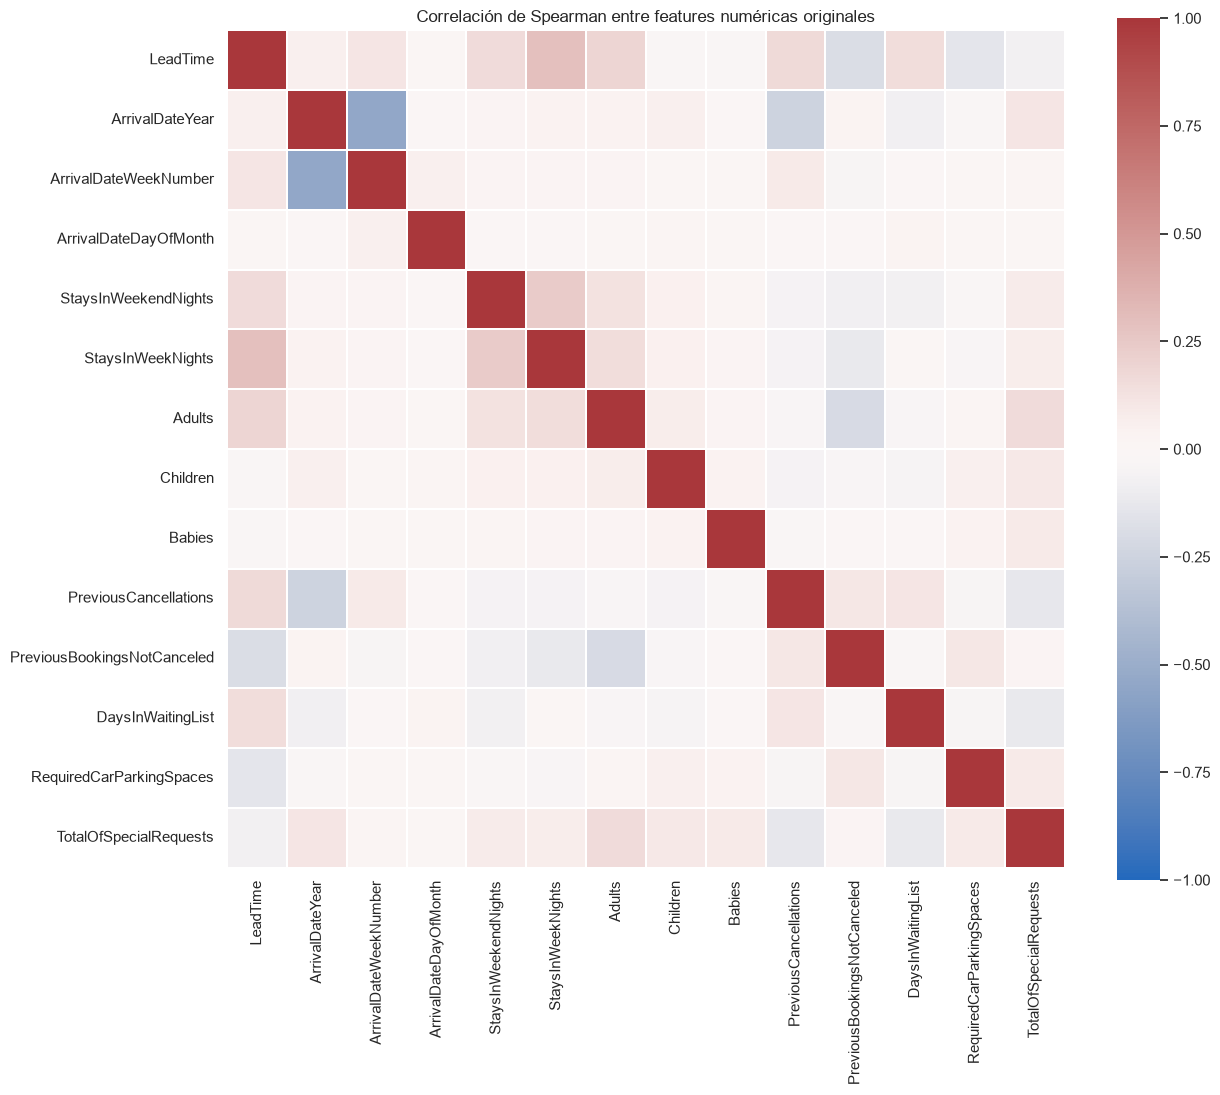

In [47]:
numeric_feature_correlation = X_structured_candidates[
    ORIGINAL_NUMERIC_FEATURES
].corr(method="spearman")

numeric_pair_records = []
for left_index, left_feature in enumerate(ORIGINAL_NUMERIC_FEATURES):
    for right_feature in ORIGINAL_NUMERIC_FEATURES[left_index + 1:]:
        correlation = numeric_feature_correlation.loc[left_feature, right_feature]
        numeric_pair_records.append({
            "feature_1": left_feature,
            "feature_2": right_feature,
            "spearman": correlation,
            "absolute_association": abs(correlation),
        })
numeric_feature_pairs = pd.DataFrame(numeric_pair_records).sort_values(
    "absolute_association", ascending=False
)
display(numeric_feature_pairs.head(20).round(4))
display(numeric_feature_pairs.loc[
    numeric_feature_pairs["absolute_association"].ge(0.70)
].round(4))

figure, axis = plt.subplots(figsize=(13, 11))
sns.heatmap(
    numeric_feature_correlation, cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, ax=axis,
)
axis.set_title("Correlación de Spearman entre features numéricas originales")
figure.tight_layout()
numeric_correlation_path = PROJECT_ROOT / "outputs" / "figures" / "feature_analysis_numeric_feature_correlations.png"
figure.savefig(numeric_correlation_path, dpi=300, bbox_inches="tight")
print(f"Gráfica guardada en: {numeric_correlation_path}")
plt.show()

## Factor de inflación de la varianza

El VIF complementa las correlaciones por pares: mide cuánto puede explicarse una numérica mediante la combinación lineal de las demás. Se calcula después de imputar medianas, únicamente como diagnóstico sobre las numéricas originales. Valores mayores a 5 requieren atención y mayores a 10 sugieren multicolinealidad fuerte. No se extiende al One-Hot completo por su alta dimensionalidad y dependencias propias de la codificación.

In [48]:
from sklearn.linear_model import LinearRegression

vif_numeric_data = (
    X_structured_candidates[ORIGINAL_NUMERIC_FEATURES]
    .apply(pd.to_numeric, errors="coerce")
)
vif_numeric_data = vif_numeric_data.fillna(vif_numeric_data.median())
non_constant_numeric_features = [
    column for column in vif_numeric_data.columns
    if vif_numeric_data[column].nunique() > 1
]
vif_records = []
for feature in non_constant_numeric_features:
    other_features = [
        column for column in non_constant_numeric_features if column != feature
    ]
    auxiliary_model = LinearRegression(n_jobs=-1)
    auxiliary_model.fit(vif_numeric_data[other_features], vif_numeric_data[feature])
    r_squared = auxiliary_model.score(
        vif_numeric_data[other_features], vif_numeric_data[feature]
    )
    vif = np.inf if r_squared >= 1 else 1 / (1 - r_squared)
    vif_records.append({
        "feature": feature,
        "r_squared_against_other_numeric_features": r_squared,
        "vif": vif,
    })

numeric_vif_summary = pd.DataFrame(vif_records).sort_values("vif", ascending=False)
display(numeric_vif_summary.round(4))

,feature,r_squared_against_other_numeric_features,vif
1,ArrivalDateYear,0.3422,1.5203
2,ArrivalDateWeekNumber,0.3326,1.4983
5,StaysInWeekNights,0.2687,1.3675
4,StaysInWeekendNights,0.2556,1.3434
0,LeadTime,0.1372,1.1590
13,TotalOfSpecialRequests,0.0792,1.0860
9,PreviousCancellations,0.0544,1.0575
6,Adults,0.0501,1.0527
10,PreviousBookingsNotCanceled,0.0491,1.0516
11,DaysInWaitingList,0.0432,1.0452


## Matriz de asociación para tipos mixtos

Las categorías con menos de 100 observaciones se agrupan para estabilizar V de Cramér y $\eta$. La matriz usa magnitudes entre 0 y 1: no conserva el signo de Spearman y no debe interpretarse como una única clase de coeficiente. Se listan por separado los pares con asociación al menos 0,70.

In [49]:
def correlation_ratio(categories, numeric_values):
    """Calcula eta entre una categórica y una numérica."""
    analysis_frame = pd.DataFrame({
        "category": categories, "value": numeric_values
    }).dropna(subset=["value"])
    if analysis_frame.empty or analysis_frame["value"].var(ddof=0) == 0:
        return 0.0
    overall_mean = analysis_frame["value"].mean()
    grouped = analysis_frame.groupby("category", observed=True)["value"].agg(["count", "mean"])
    between_group_variation = (
        grouped["count"] * (grouped["mean"] - overall_mean) ** 2
    ).sum()
    total_variation = ((analysis_frame["value"] - overall_mean) ** 2).sum()
    return np.sqrt(between_group_variation / total_variation) if total_variation > 0 else 0.0


prepared_original_categories = {
    feature: prepare_categorical_for_association(X_structured_candidates[feature])
    for feature in ORIGINAL_CATEGORICAL_FEATURES
}

,feature_1,feature_2,metric,association
69,ArrivalDateMonth,ArrivalDateWeekNumber,Correlation ratio eta,0.9951
244,MarketSegment,HasCompany,Corrected Cramer's V,0.7711
254,DistributionChannel,HasCompany,Corrected Cramer's V,0.7426
234,MarketSegment,DistributionChannel,Corrected Cramer's V,0.6919
253,DistributionChannel,HasAgent,Corrected Cramer's V,0.6757
243,MarketSegment,HasAgent,Corrected Cramer's V,0.6647
188,Children,ReservedRoomType,Correlation ratio eta,0.6417
299,HasAgent,HasCompany,Corrected Cramer's V,0.5941
47,ArrivalDateYear,ArrivalDateMonth,Correlation ratio eta,0.5867
48,ArrivalDateYear,ArrivalDateWeekNumber,Absolute Spearman,0.5448


,feature_1,feature_2,metric,association
69,ArrivalDateMonth,ArrivalDateWeekNumber,Correlation ratio eta,0.9951
244,MarketSegment,HasCompany,Corrected Cramer's V,0.7711
254,DistributionChannel,HasCompany,Corrected Cramer's V,0.7426


Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_mixed_feature_associations.png


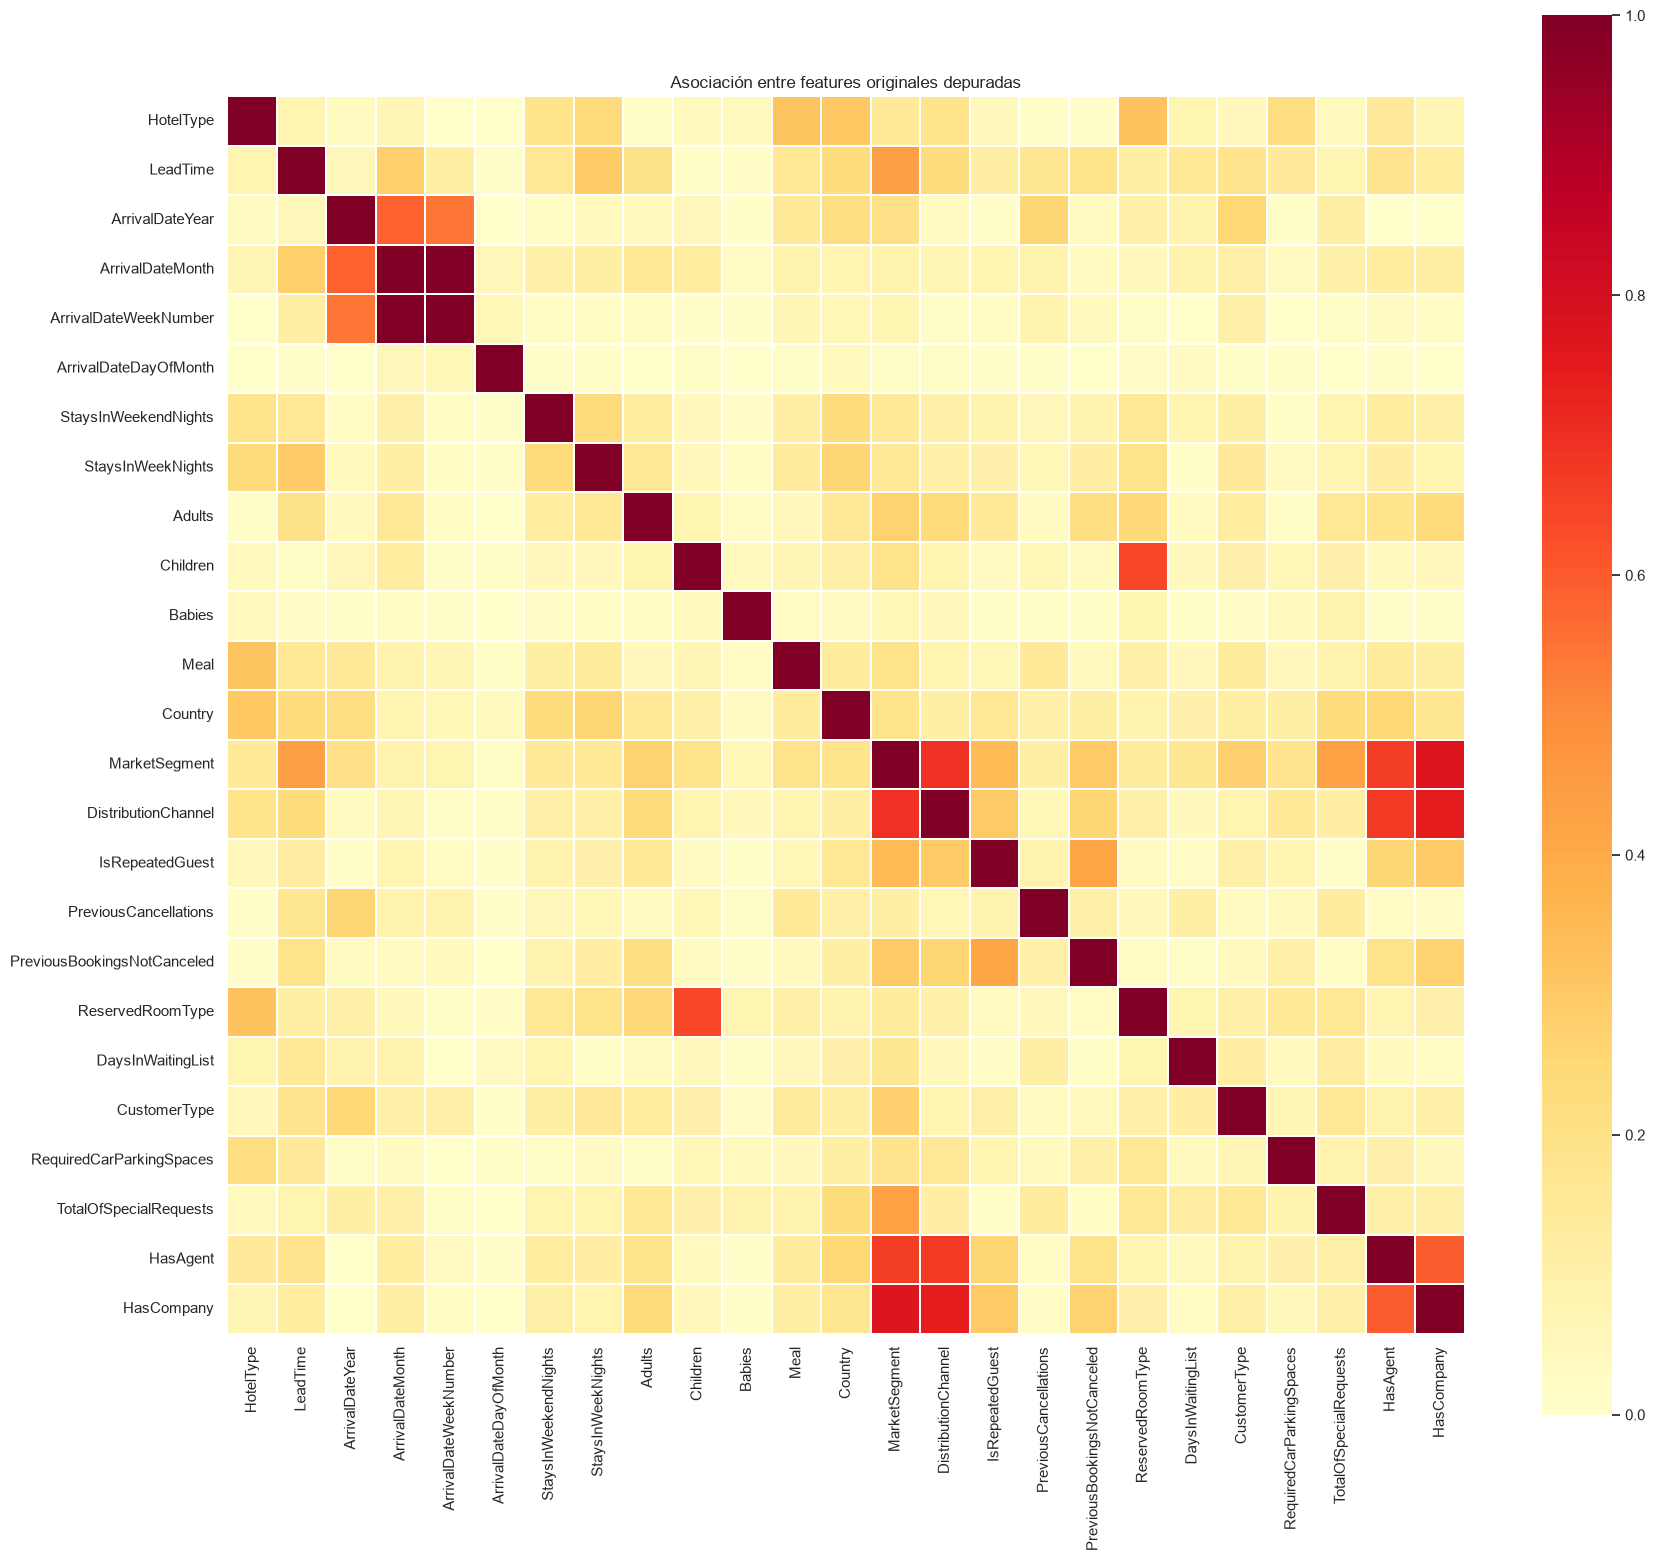

In [50]:
original_feature_order = list(X_structured_candidates.columns)
mixed_association_matrix = pd.DataFrame(
    np.eye(len(original_feature_order)),
    index=original_feature_order,
    columns=original_feature_order,
)
mixed_pair_records = []

for left_index, left_feature in enumerate(original_feature_order):
    for right_feature in original_feature_order[left_index + 1:]:
        left_is_categorical = left_feature in ORIGINAL_CATEGORICAL_FEATURES
        right_is_categorical = right_feature in ORIGINAL_CATEGORICAL_FEATURES

        if not left_is_categorical and not right_is_categorical:
            association = abs(numeric_feature_correlation.loc[left_feature, right_feature])
            metric = "Absolute Spearman"
        elif left_is_categorical and right_is_categorical:
            contingency = pd.crosstab(
                prepared_original_categories[left_feature],
                prepared_original_categories[right_feature],
            )
            association = corrected_cramers_v(contingency)["cramers_v"]
            metric = "Corrected Cramer's V"
        else:
            categorical_feature = left_feature if left_is_categorical else right_feature
            numeric_feature = right_feature if left_is_categorical else left_feature
            association = correlation_ratio(
                prepared_original_categories[categorical_feature],
                X_structured_candidates[numeric_feature],
            )
            metric = "Correlation ratio eta"

        mixed_association_matrix.loc[left_feature, right_feature] = association
        mixed_association_matrix.loc[right_feature, left_feature] = association
        mixed_pair_records.append({
            "feature_1": left_feature, "feature_2": right_feature,
            "metric": metric, "association": association,
        })

mixed_feature_pairs = pd.DataFrame(mixed_pair_records).sort_values("association", ascending=False)
display(mixed_feature_pairs.head(30).round(4))
display(mixed_feature_pairs.loc[mixed_feature_pairs["association"].ge(0.70)].round(4))

figure, axis = plt.subplots(figsize=(18, 16))
sns.heatmap(
    mixed_association_matrix, cmap="YlOrRd", vmin=0, vmax=1,
    square=True, linewidths=0.2, ax=axis,
)
axis.set_title("Asociación entre features originales depuradas")
figure.tight_layout()
mixed_association_path = PROJECT_ROOT / "outputs" / "figures" / "feature_analysis_mixed_feature_associations.png"
figure.savefig(mixed_association_path, dpi=300, bbox_inches="tight")
print(f"Gráfica guardada en: {mixed_association_path}")
plt.show()

## Criterio de decisión

Las asociaciones altas se revisarán por significado antes de eliminar variables. En Logistic Regression, redundancias fuertes pueden desestabilizar coeficientes aunque la regularización preserve el desempeño. En árboles, variables relacionadas pueden repartir sus importancias sin perjudicar necesariamente la predicción. Las decisiones definitivas se confirmarán mediante validación y ablación, no sólo con umbrales de correlación o VIF.

# Conclusiones de Feature Analysis

El análisis permitió separar asociaciones descriptivas de señales utilizables en el momento definido para la predicción. Las decisiones de esta sección determinan el conjunto inicial de Feature Engineering, pero no reemplazan la validación multivariada posterior.

## Variables excluidas

- `ReservationStatus` y `ReservationStatusDate`: describen directamente el resultado de la reserva.
- `AssignedRoomType` y `BookingChanges`: pueden contener información registrada después de la confirmación.
- `DepositType`: su definición depende de pagos acumulados antes de la llegada o cancelación y no garantiza disponibilidad en el instante de predicción.
- `ADR`: presenta valores extremos, una asociación marginal débil y una definición transaccional cuyo corte temporal no está garantizado.
- `Agent` y `Company` como identificadores: tienen alta cardinalidad, entidades nuevas entre períodos y riesgo de memorizar actores particulares.

## Transformaciones acordadas

- Reemplazar los identificadores `Agent` y `Company` por `HasAgent` y `HasCompany`.
- Mantener `Country` como variable nominal y evaluar una representación agrupada o un indicador como `IsDomestic` sin utilizar estadísticas del target fuera de los folds.
- Crear `TotalGuests` y `TotalNights` como candidatas interpretables, sin eliminar inicialmente sus componentes.
- Excluir `ArrivalDateWeekNumber` después del baseline: su asociación con `ArrivalDateMonth` es prácticamente determinística ($\eta=0{,}9951$) y mes, año y día conservan una representación temporal más interpretable.

## Variables que requieren validación especial

- `DaysInWaitingList`: su relación cambia según hotel y período; se conserva provisionalmente para árboles y se evaluará con interacciones o una versión binaria en modelos lineales.
- `PreviousCancellations`, `RequiredCarParkingSpaces` y `TotalOfSpecialRequests`: muestran señales descriptivas relevantes, aunque algunas categorías son poco frecuentes.
- `TotalGuests` y `TotalNights`: son útiles conceptualmente, pero no mejoran por sí solas el ROC AUC de sus mejores componentes.
- Los casos sin huéspedes, sin noches y los extremos poco frecuentes se conservan; cualquier tratamiento especial deberá justificarse dentro del pipeline.

## Criterio para la siguiente etapa

Feature Engineering implementará estas decisiones mediante transformaciones reproducibles. Las features nuevas se compararán contra un conjunto base mediante validación compatible con la estructura temporal y los patrones repetidos del dataset. La selección final se realizará por desempeño fuera de muestra, estabilidad entre folds e interpretación, evitando decidir únicamente por asociaciones observadas sobre el dataset completo.